# Counterfactual Inflation Analysis  
## What If Ukraine Had Been Part of the Euro Area?

**Quantitative Methods in Finance - Final Project**  
**Master 2 Finance, Technology and Data - Université Paris 1 Panthéon-Sorbonne**

---

## Executive summary

This notebook constructs the preliminary monetary-regime analysis required before estimating a counterfactual inflation path for Ukraine under hypothetical Euro Area membership.

The key argument is that Ukraine's monetary sovereignty was **time-varying**. During de facto or formal exchange-rate pegs, monetary policy was constrained by the exchange-rate anchor. During crisis devaluations and the post-2015/2016 inflation-targeting period, Ukraine exercised more genuine monetary autonomy. This matters directly for the counterfactual: Euro Area membership should not be modelled as a constant treatment over the full sample.

**Main preliminary analysis contribution:** the treatment intensity of Euro Area membership is low during peg episodes, high during crisis/floating episodes, and intermediate after the adoption of inflation targeting.


# Notebook structure

1. **Part A - Ukraine’s Monetary Regime**: documented chronology, peg episodes, devaluations, capital controls, transition to inflation targeting, IMF-style de facto classification, and implications for the counterfactual design.

2. **Part B - Counterfactual Inflation Analysis**: data pipeline, Ukrainian CPI harmonisation, econometric identification, a structural Blanchard–Quah SVAR benchmark, counterfactual inflation paths, interpretation and robustness checks.



# Part A - Ukraine’s Monetary Regime: Preliminary Analysis

## 1. Why Preliminary Analysis matters

Before constructing a counterfactual inflation path, one must understand what Ukraine actually did with its monetary sovereignty. A naïve interpretation would assume that Ukraine continuously had a freely floating exchange rate and an independent monetary policy. That interpretation is misleading.

From 2000 onward, Ukraine alternated between long phases of de facto exchange-rate stabilisation against the US dollar, sudden exchange-rate collapses during crises, emergency capital controls, a post-2015 transition toward inflation targeting and a floating exchange rate, a return to a hard wartime peg in February 2022, and a gradual move to managed exchange-rate flexibility from October 2023.

This chronology is not background information only. It defines the economic meaning of the counterfactual. If Ukraine was already operating under a dollar anchor, Euro Area membership would not represent the same treatment as during periods in which Ukraine used devaluation or independent monetary policy as adjustment tools.

> **The counterfactual treatment (Euro Area membership) is time-varying because Ukraine's de facto monetary sovereignty was time-varying.**


## 2. Sources and evidence used in Part A

The chronology below relies on institutional and academic sources, with priority given to primary sources.

**Primary institutional sources:** NBU official exchange-rate API; NBU official exchange-rate, FX-restrictions, and inflation-targeting pages; IMF country reports and Article IV/programme documents; IMF AREAER database and annual reports.

**Academic / conceptual sources:** Calvo and Reinhart (2002), Mundell (1961), McKinnon (1963), Kenen (1969), Barro and Gordon (1983), Giavazzi and Pagano (1988), and De Grauwe (2012).

**Precision note.** The column labelled “IMF-style de facto classification” uses the IMF's exchange-rate taxonomy. When an exact annual AREAER label is available from IMF country-report evidence, it is stated as such. Otherwise, the classification is an informed de facto assessment based on the NBU exchange-rate path, IMF programme reports, and the IMF AREAER taxonomy. This avoids over-claiming precision while satisfying the identification role of Part A.


## 3. Chronology of Ukraine’s monetary regime, 2000–2025

The table below is the main deliverable for Part A. It identifies the regime phases that will be used later to discipline the counterfactual design.


In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_colwidth', 120)

regime_table = pd.DataFrame({
    "Period": [
        "2000–2004", "2005–mid-2008", "late-2008–2009", "2010–Feb. 2014",
        "Mar. 2014–2015", "2016–Feb. 2022", "24 Feb. 2022–20 Jul. 2022",
        "21 Jul. 2022–2 Oct. 2023", "3 Oct. 2023–2025"
    ],
    "Approx. UAH/USD rate": [
        "~5.3–5.4", "~5.05, then ~4.85 in 2008", "Depreciation toward ~8.0", "~7.9–8.0",
        "Sharp depreciation; around ~15–25+ at stress points", "Flexible/managed float; roughly ~24–29 before invasion",
        "Fixed at 29.2549", "Fixed at 36.5686", "Managed flexibility; gradual depreciation"
    ],
    "IMF-style de facto classification": [
        "Stabilized arrangement / conventional-peg-like USD anchor",
        "Stabilized arrangement / crawling or narrow-band USD anchor",
        "Crisis float / other managed arrangement",
        "Stabilized arrangement / de facto USD peg",
        "Floating or managed floating under crisis conditions",
        "Floating / managed float with inflation targeting",
        "Hard peg to the US dollar under martial law",
        "Hard peg to the US dollar under martial law",
        "Managed exchange-rate flexibility; IMF reports reclassification from stabilized to floating effective 3 Oct. 2023"
    ],
    "Capital controls / FX restrictions": [
        "Limited relative to crisis periods", "Limited, but macro-financial vulnerabilities accumulated",
        "Crisis measures and interventions", "Controls and administrative measures progressively tightened as pressures rose",
        "Significant emergency FX restrictions and capital controls", "Progressive liberalisation; new FX-regulation framework in 2019",
        "Strict wartime FX restrictions and capital-flow management measures", "Strict wartime FX restrictions, gradually adjusted",
        "Gradual easing of FX restrictions under managed flexibility"
    ],
    "Key events and interpretation": [
        "Exchange rate used as the main nominal anchor; limited effective monetary autonomy.",
        "Stability of the hryvnia reinforced credibility but encouraged FX imbalances.",
        "Global Financial Crisis; peg pressure; reserves loss and sharp devaluation.",
        "Return to a de facto dollar anchor; the effective peg was abandoned in early 2014.",
        "Maidan, Crimea annexation, Donbas conflict, banking stress, inflation surge.",
        "Inflation targeting became the main monetary-policy framework; more genuine monetary sovereignty.",
        "Full-scale invasion; fixed rate and strict controls to prevent panic and preserve financial stability.",
        "July 2022 repeg/devaluation by 25% to 36.5686 UAH/USD.",
        "October 2023 shift from peg to managed flexibility; exchange rate allowed to respond to demand/supply while NBU remains active."
    ]
})
regime_table


,Period,Approx. UAH/USD rate,IMF-style de facto classification,Capital controls / FX restrictions,Key events and interpretation
0,2000–2004,~5.3–5.4,Stabilized arrangement / conventional-peg-like USD anchor,Limited relative to crisis periods,Exchange rate used as the main nominal anchor; limited effective monetary autonomy.
1,2005–mid-2008,"~5.05, then ~4.85 in 2008",Stabilized arrangement / crawling or narrow-band USD anchor,"Limited, but macro-financial vulnerabilities accumulated",Stability of the hryvnia reinforced credibility but encouraged FX imbalances.
2,late-2008–2009,Depreciation toward ~8.0,Crisis float / other managed arrangement,Crisis measures and interventions,Global Financial Crisis; peg pressure; reserves loss and sharp devaluation.
3,2010–Feb. 2014,~7.9–8.0,Stabilized arrangement / de facto USD peg,Controls and administrative measures progressively tightened as pressures rose,Return to a de facto dollar anchor; the effective peg was abandoned in early 2014.
4,Mar. 2014–2015,Sharp depreciation; around ~15–25+ at stress points,Floating or managed floating under crisis conditions,Significant emergency FX restrictions and capital controls,"Maidan, Crimea annexation, Donbas conflict, banking stress, inflation surge."
5,2016–Feb. 2022,Flexible/managed float; roughly ~24–29 before invasion,Floating / managed float with inflation targeting,Progressive liberalisation; new FX-regulation framework in 2019,Inflation targeting became the main monetary-policy framework; more genuine monetary sovereignty.
6,24 Feb. 2022–20 Jul. 2022,Fixed at 29.2549,Hard peg to the US dollar under martial law,Strict wartime FX restrictions and capital-flow management measures,Full-scale invasion; fixed rate and strict controls to prevent panic and preserve financial stability.
7,21 Jul. 2022–2 Oct. 2023,Fixed at 36.5686,Hard peg to the US dollar under martial law,"Strict wartime FX restrictions, gradually adjusted",July 2022 repeg/devaluation by 25% to 36.5686 UAH/USD.
8,3 Oct. 2023–2025,Managed flexibility; gradual depreciation,Managed exchange-rate flexibility; IMF reports reclassification from stabilized to floating effective 3 Oct. 2023,Gradual easing of FX restrictions under managed flexibility,October 2023 shift from peg to managed flexibility; exchange rate allowed to respond to demand/supply while NBU rema...


## 4. Official UAH/USD data from the National Bank of Ukraine

The exchange-rate graph below is constructed from **actual official National Bank of Ukraine (NBU) data** downloaded through the NBU public API. **No simulated or stylised exchange-rate data are used in this section.**

For historical exchange-rate ranges, the notebook uses the NBU endpoint:

`https://bank.gov.ua/NBU_Exchange/exchange_site?start=YYYYMMDD&end=YYYYMMDD&valcode=USD&sort=exchangedate&order=asc&json`

A key technical issue is that the NBU API can report the raw `rate` field for several units of a currency. For older USD observations, the `rate` field may correspond to **100 USD** rather than **1 USD**. Therefore, the code below uses `rate_per_unit` when available, and otherwise computes:

`UAH per USD = rate / units`

This avoids the artificial scale problem in which the exchange rate appears around 500, 800, or 2,700 instead of approximately 5, 8, or 27 UAH/USD.

The final monthly series is saved as:

- `data/nbu_usd_uah_daily.csv`
- `data/nbu_usd_uah_monthly.csv`

and the figure is saved as:

- `figures/partA_uah_usd_exchange_rate_nbu.png`


In [79]:
# ============================================================
# 4. Official UAH/USD data from the National Bank of Ukraine
# ============================================================

import pandas as pd
import requests
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("data")
FIG_DIR = Path("figures")
DATA_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Source:
# National Bank of Ukraine API — official exchange rates
# Historical endpoint:
# https://bank.gov.ua/NBU_Exchange/exchange_site
#
# Important:
# The NBU API may report exchange rates for several currency units.
# For USD, older observations can be reported for 100 USD.
# Therefore, we must use 'rate_per_unit' when available,
# or compute rate / units.
# ------------------------------------------------------------

def _parse_nbu_response(json_data, requested_year):
    """
    Parse one NBU API response and return a clean dataframe.

    The key point is to avoid using the raw 'rate' field directly,
    because the NBU API can report rates for multiple currency units.
    The correct UAH/USD rate is:
        - rate_per_unit, if available;
        - otherwise rate / units.
    """

    if not json_data:
        raise ValueError(f"The NBU API returned no data for year {requested_year}.")

    df = pd.DataFrame(json_data)

    # Date field is usually 'exchangedate', formatted as DD.MM.YYYY.
    if "exchangedate" not in df.columns:
        raise ValueError(
            f"Unexpected NBU API format for year {requested_year}: "
            f"'exchangedate' field not found. Columns returned: {list(df.columns)}"
        )

    df["date"] = pd.to_datetime(df["exchangedate"], format="%d.%m.%Y", errors="coerce")

    # Raw rate field.
    if "rate" not in df.columns:
        raise ValueError(
            f"Unexpected NBU API format for year {requested_year}: "
            f"'rate' field not found. Columns returned: {list(df.columns)}"
        )

    df["rate"] = pd.to_numeric(df["rate"], errors="coerce")

    # Units field: sometimes the API reports rates for 100 units of a currency.
    if "units" in df.columns:
        df["units"] = pd.to_numeric(df["units"], errors="coerce").fillna(1)
    else:
        df["units"] = 1

    # Correct rate per one USD.
    if "rate_per_unit" in df.columns:
        df["rate_per_unit"] = pd.to_numeric(df["rate_per_unit"], errors="coerce")
        df["uah_per_usd"] = df["rate_per_unit"].fillna(df["rate"] / df["units"])
    else:
        df["uah_per_usd"] = df["rate"] / df["units"]

    df = (
        df[["date", "uah_per_usd"]]
        .dropna()
        .sort_values("date")
        .reset_index(drop=True)
    )

    # Safety check: the endpoint must return data for the requested year.
    returned_years = sorted(df["date"].dt.year.unique())

    if requested_year not in returned_years:
        raise ValueError(
            f"The NBU API returned dates outside the requested year {requested_year}. "
            f"Returned years: {returned_years}. "
            "This usually means that the query was interpreted incorrectly."
        )

    # Keep only the requested year, in case the API returns surrounding dates.
    df = df[df["date"].dt.year == requested_year].copy()

    return df


def download_nbu_usd_uah(start_year=2000, end_year=2025, save_path=DATA_DIR / "nbu_usd_uah_daily.csv"):
    """
    Download official daily UAH/USD exchange rates from the NBU API,
    year by year, from start_year to end_year.

    Returns
    -------
    pandas.DataFrame
        Columns: date, uah_per_usd
    """

    frames = []

    for year in range(start_year, end_year + 1):
        start = f"{year}0101"
        end = f"{year}1231"

        url = (
            "https://bank.gov.ua/NBU_Exchange/exchange_site"
            f"?start={start}&end={end}&valcode=USD"
            "&sort=exchangedate&order=asc&json"
        )

        print(f"Downloading NBU UAH/USD data for {year}...")

        response = requests.get(url, timeout=60)
        response.raise_for_status()

        df_year = _parse_nbu_response(response.json(), requested_year=year)
        frames.append(df_year)

    df = (
        pd.concat(frames, ignore_index=True)
        .drop_duplicates(subset="date")
        .sort_values("date")
        .reset_index(drop=True)
    )

    # Final quality checks.
    if len(df) < 1000:
        raise ValueError(
            f"Only {len(df)} observations were downloaded. "
            "This is suspiciously low for daily data from 2000 to 2025."
        )

    if df["uah_per_usd"].max() > 100:
        raise ValueError(
            "The maximum UAH/USD value is above 100. "
            "This suggests that the rate was not converted to a per-unit basis. "
            "Check the 'units' and 'rate_per_unit' fields."
        )

    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(save_path, index=False)

    print("\nDownload completed.")
    print(f"Daily observations: {len(df):,}")
    print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
    print(f"Minimum UAH/USD: {df['uah_per_usd'].min():.2f}")
    print(f"Maximum UAH/USD: {df['uah_per_usd'].max():.2f}")

    display(df.head())
    display(df.tail())

    return df


# Download daily official UAH/USD data.
nbu_daily = download_nbu_usd_uah(start_year=2000, end_year=2025)

# Convert daily official rates into monthly averages.
nbu_monthly = (
    nbu_daily
    .set_index("date")
    .resample("MS")["uah_per_usd"]
    .mean()
    .reset_index()
)

monthly_path = DATA_DIR / "nbu_usd_uah_monthly.csv"
nbu_monthly.to_csv(monthly_path, index=False)

print("\nMonthly aggregation completed.")
print(f"Monthly observations: {len(nbu_monthly):,}")
display(nbu_monthly.head())
display(nbu_monthly.tail())



Download completed.
Daily observations: 9,497
Date range: 2000-01-01 to 2025-12-31
Minimum UAH/USD: 4.84
Maximum UAH/USD: 42.40


,date,uah_per_usd
0,2000-01-01,5.2163
1,2000-01-02,5.2163
2,2000-01-03,5.2163
3,2000-01-04,5.2163
4,2000-01-05,5.2163


,date,uah_per_usd
9492,2025-12-27,41.9331
9493,2025-12-28,41.9331
9494,2025-12-29,42.0637
9495,2025-12-30,42.2179
9496,2025-12-31,42.3878



Monthly aggregation completed.
Monthly observations: 312


,date,uah_per_usd
0,2000-01-01,5.381058
1,2000-02-01,5.543114
2,2000-03-01,5.467974
3,2000-04-01,5.422750
4,2000-05-01,5.404077


,date,uah_per_usd
307,2025-08-01,41.441897
308,2025-09-01,41.318337
309,2025-10-01,41.627123
310,2025-11-01,42.104007
311,2025-12-01,42.199929


Figure saved to: figures/partA_uah_usd_exchange_rate_nbu.png


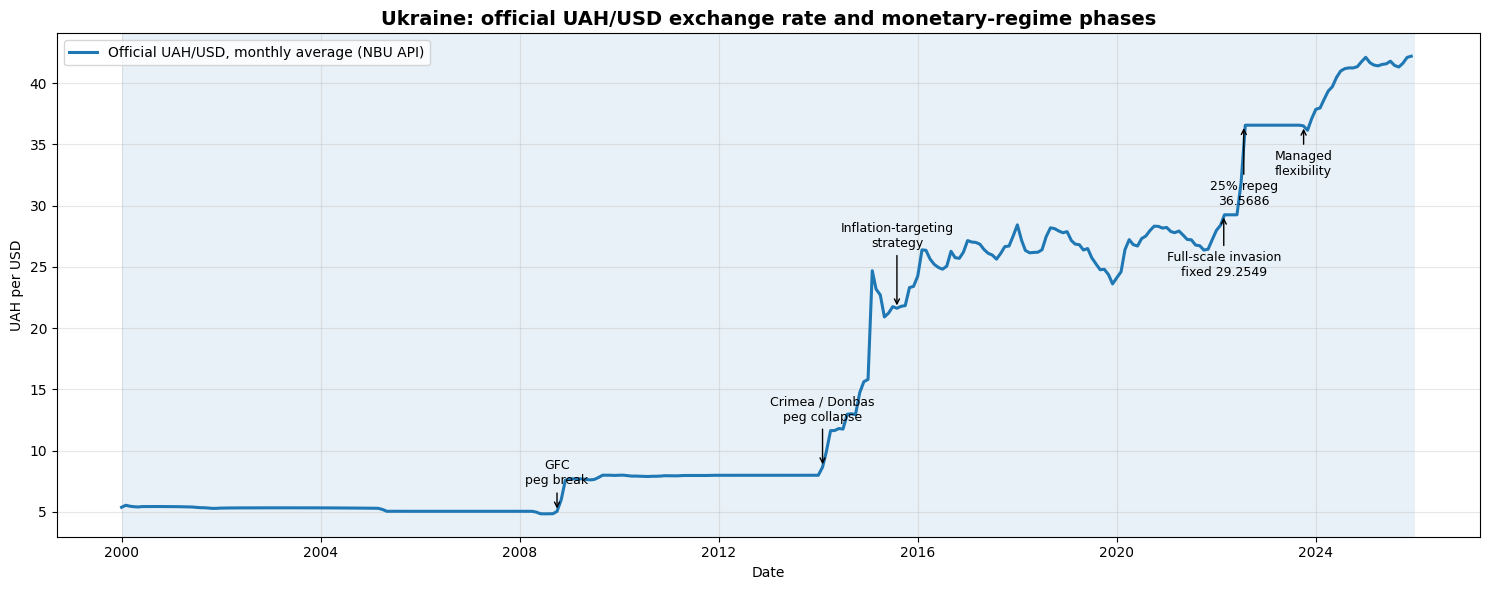

In [80]:
# ------------------------------------------------------------
# Plot official UAH/USD exchange rate and monetary-regime phases
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(
    nbu_monthly["date"],
    nbu_monthly["uah_per_usd"],
    linewidth=2.2,
    label="Official UAH/USD, monthly average (NBU API)"
)

# Monetary regime phases used in Part A.
# The shaded bands are deliberately left unlabeled here to avoid visual clutter;
# the detailed regime labels are shown in the timeline graph immediately below.
regime_phases = [
    ("De facto USD peg", "2000-01-01", "2008-09-01"),
    ("GFC adjustment", "2008-09-01", "2010-01-01"),
    ("Renewed de facto peg", "2010-01-01", "2014-02-01"),
    ("Crimea–Donbas crisis", "2014-02-01", "2015-12-31"),
    ("Inflation targeting / managed float", "2016-01-01", "2022-02-24"),
    ("Wartime fixed rate", "2022-02-24", "2023-10-03"),
    ("Managed flexibility", "2023-10-03", "2025-12-31"),
]

for label, start, end in regime_phases:
    ax.axvspan(pd.to_datetime(start), pd.to_datetime(end), alpha=0.10)

# Key event annotations. The offsets are chosen to reduce overlap.
events = [
    ("GFC\npeg break", "2008-10-01", 2.2),
    ("Crimea / Donbas\npeg collapse", "2014-02-01", 3.8),
    ("Inflation-targeting\nstrategy", "2015-08-01", 5.0),
    ("Full-scale invasion\nfixed 29.2549", "2022-02-24", -5.0),
    ("25% repeg\n36.5686", "2022-07-21", -6.5),
    ("Managed\nflexibility", "2023-10-03", -4.0),
]

for text, date, y_offset in events:
    event_date = pd.to_datetime(date)
    nearest_idx = (nbu_monthly["date"] - event_date).abs().idxmin()
    y_value = nbu_monthly.loc[nearest_idx, "uah_per_usd"]

    ax.annotate(
        text,
        xy=(event_date, y_value),
        xytext=(event_date, y_value + y_offset),
        arrowprops=dict(arrowstyle="->", lw=1),
        fontsize=9,
        ha="center"
    )

ax.set_title(
    "Ukraine: official UAH/USD exchange rate and monetary-regime phases",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel("Date")
ax.set_ylabel("UAH per USD")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)

plt.tight_layout()

fig_path = FIG_DIR / "partA_uah_usd_exchange_rate_nbu.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
print(f"Figure saved to: {fig_path}")

plt.show()


**Reading of the exchange-rate figure.** The official UAH/USD series confirms that Ukraine cannot be described as a continuous floating-regime economy. Long phases of de facto stabilisation were interrupted by sharp regime breaks: the 2008–2009 depreciation, the 2014–2015 collapse of the peg, and the wartime fixed-rate regime after February 2022. These breaks are precisely the periods in which monetary sovereignty matters most for the counterfactual.

## 5. Timeline visualisation of monetary-regime phases

The following timeline makes the time-varying nature of monetary sovereignty visually explicit.


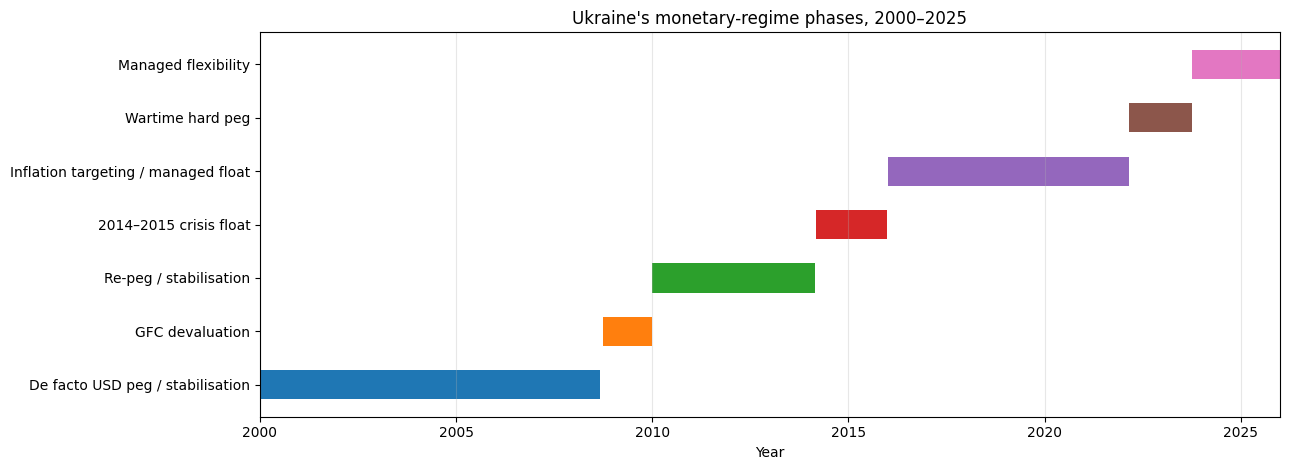

In [81]:
timeline = pd.DataFrame({
    "Regime": ["De facto USD peg / stabilisation", "GFC devaluation", "Re-peg / stabilisation", "2014–2015 crisis float", "Inflation targeting / managed float", "Wartime hard peg", "Managed flexibility"],
    "Start": [2000.0, 2008.75, 2010.0, 2014.17, 2016.0, 2022.15, 2023.76],
    "End": [2008.67, 2009.99, 2014.16, 2015.99, 2022.14, 2023.75, 2025.99]
})
timeline["Duration"] = timeline["End"] - timeline["Start"]
fig, ax = plt.subplots(figsize=(13, 4.8))
for _, row in timeline.iterrows():
    ax.barh(row["Regime"], row["Duration"], left=row["Start"], height=0.55)
ax.set_xlim(2000, 2026)
ax.set_xlabel("Year")
ax.set_title("Ukraine's monetary-regime phases, 2000–2025")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "partA_monetary_regime_timeline.png", dpi=300)
plt.show()


## 6. Major devaluation episodes

### 6.1 Global Financial Crisis, 2008-2009

Before the Global Financial Crisis, Ukraine maintained a relatively stable exchange rate against the US dollar. IMF staff reports at the time described the exchange-rate anchor as constraining monetary policy and recommended greater exchange-rate flexibility as a way to give monetary policy more scope.

The crisis exposed the fragility of the regime. External financing conditions tightened, reserves came under pressure, and the hryvnia depreciated sharply from around 5 UAH/USD toward 8 UAH/USD. This episode illustrates the cost of accumulating imbalances under a peg: the exchange-rate adjustment, when it finally occurs, is abrupt and inflationary.

### 6.2 Crimea and Donbas crisis, 2014-2015

The second major break occurred after the Maidan revolution, Russia's annexation of Crimea, and the outbreak of conflict in Donbas. IMF documents note that by March 2014 Ukraine was in a currency, banking, balance-of-payments, and political crisis; the effective peg was abandoned and the hryvnia depreciated rapidly.

The NBU and the IMF programme shifted the policy framework toward a more flexible exchange rate and domestic price stability. However, in practice, this transition took place under severe crisis conditions, with large capital outflows, banking stress, and administrative restrictions.

### 6.3 Full-scale invasion, 2022

On 24 February 2022, following Russia's full-scale invasion, the NBU fixed the official exchange rate at **29.2549 UAH/USD** and imposed strict FX restrictions and capital-flow management measures. This was an emergency stabilisation framework, not a normal monetary regime.

On 21 July 2022, the NBU adjusted the official fixed exchange rate by 25%, to **36.5686 UAH/USD**. The fixed rate remained in place until the transition to managed exchange-rate flexibility on 3 October 2023.

### 6.4 Managed flexibility from October 2023

Effective 3 October 2023, the NBU shifted from the wartime hard peg to managed exchange-rate flexibility. IMF reports describe this as an exit from the peg and a step toward strengthening resilience to external shocks. The NBU did not move to a free float: it continued to intervene and cover the structural deficit of foreign currency, while allowing the exchange rate to move in response to supply and demand.


## 7. Capital controls and the impossible trinity

Ukraine's monetary history is a textbook example of the impossible trinity. A country cannot simultaneously maintain a fixed exchange rate, free capital mobility, and independent monetary policy.

When Ukraine stabilised the exchange rate against the US dollar, monetary autonomy was constrained. When capital-flow pressure intensified, the NBU either had to abandon the peg, use reserves, or impose restrictions.

Key episodes include crisis management in 2008–2009, emergency FX restrictions in 2014–2015, pre-war liberalisation through the 2019 FX-regulation framework, wartime fixed exchange rates and harsh FX restrictions from 24 February 2022, and gradual easing under managed flexibility from October 2023.

This matters for the counterfactual because Euro Area membership would remove exchange-rate policy entirely. During peg periods, Ukraine had already partly given up this instrument; during floating or devaluation episodes, the loss would have been much more consequential.


## 8. Transition to inflation targeting

Ukraine's move toward inflation targeting was a major institutional break.

The NBU's monetary-policy strategy set a medium-term inflation objective of **5%** and a gradual target path:

- **December 2016:** 12% ± 3 percentage points;
- **December 2017:** 8% ± 2 percentage points;
- **December 2018:** 6% ± 2 percentage points;
- **December 2019 and after:** 5% ± 1 percentage point.

The NBU also states that amendments to the NBU Law in 2015 strengthened the central bank's institutional independence and mandate for price stability, and that the NBU introduced inflation targeting with a floating exchange rate.

For identification, the key implication is that post-2015/2016 Ukraine is not comparable to the pre-2014 peg period. The NBU had more genuine monetary sovereignty after the reform, but this sovereignty was still fragile and shock-dependent. The full-scale invasion in 2022 forced a temporary abandonment of the inflation-targeting regime and a return to a hard exchange-rate peg.


## 9. Treatment intensity: translating this preliminary analysis into identification

The central empirical implication of this analysis is that **Euro Area membership should not be modelled as a constant treatment**.

A country already operating under a hard or quasi-hard peg has already surrendered part of its monetary autonomy. By contrast, a country using the exchange rate as a shock absorber (especially through sharp devaluations) would face a much stronger treatment under Euro Area membership, because that adjustment channel would be unavailable.

The table below converts the historical analysis into an identification device for Part B. The treatment-intensity index is **not estimated statistically**. It is a disciplined modelling device derived from the regime chronology in Part A. It assigns lower values to periods in which Ukraine was already constrained by a peg or capital controls, and higher values to periods in which independent monetary policy and exchange-rate adjustment were more relevant.

The purpose is not to measure the exact causal intensity of Euro Area membership. Rather, the index ensures that the counterfactual is consistent with the documented time-varying degree of Ukrainian monetary sovereignty.

In [82]:
treatment_intensity = pd.DataFrame({
    "Period": ["2000–2008", "2008–2009", "2010–2013", "2014–2015", "2016–Feb. 2022", "Feb. 2022–Oct. 2023", "Oct. 2023–2025"],
    "Monetary sovereignty": ["Low", "High but crisis-driven", "Low", "Very high but disorderly", "Medium-high", "Very low", "Medium-low"],
    "Euro-area treatment intensity": ["Low", "High", "Low", "Very high", "Medium-high", "Low during hard peg, but high conceptually because euro removes sovereign crisis tools", "Medium"],
    "Implication for counterfactual": [
        "Euro membership mainly changes the anchor currency and credibility, not the existence of an anchor.",
        "Euro membership removes devaluation as crisis adjustment mechanism.",
        "Small regime difference during normal times because policy was already subordinated to USD stability.",
        "Large regime difference: no hryvnia collapse, but possible internal devaluation or sovereign stress.",
        "Euro membership imports ECB credibility but removes independent inflation-targeting response.",
        "Observed regime already resembles loss of monetary autonomy, though not equivalent to euro membership.",
        "Counterfactual difference grows as Ukraine gradually regains exchange-rate flexibility."
    ]
})
treatment_intensity


,Period,Monetary sovereignty,Euro-area treatment intensity,Implication for counterfactual
0,2000–2008,Low,Low,"Euro membership mainly changes the anchor currency and credibility, not the existence of an anchor."
1,2008–2009,High but crisis-driven,High,Euro membership removes devaluation as crisis adjustment mechanism.
2,2010–2013,Low,Low,Small regime difference during normal times because policy was already subordinated to USD stability.
3,2014–2015,Very high but disorderly,Very high,"Large regime difference: no hryvnia collapse, but possible internal devaluation or sovereign stress."
4,2016–Feb. 2022,Medium-high,Medium-high,Euro membership imports ECB credibility but removes independent inflation-targeting response.
5,Feb. 2022–Oct. 2023,Very low,"Low during hard peg, but high conceptually because euro removes sovereign crisis tools","Observed regime already resembles loss of monetary autonomy, though not equivalent to euro membership."
6,Oct. 2023–2025,Medium-low,Medium,Counterfactual difference grows as Ukraine gradually regains exchange-rate flexibility.


In [83]:

# Export treatment-intensity table

from pathlib import Path

OUT_DIR = Path("outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

treatment_intensity.to_csv(
    OUT_DIR / "regime_table_partA.csv",
    index=False
)

print("Saved Part A treatment-intensity table to outputs/regime_table_partA.csv")

Saved Part A treatment-intensity table to outputs/regime_table_partA.csv


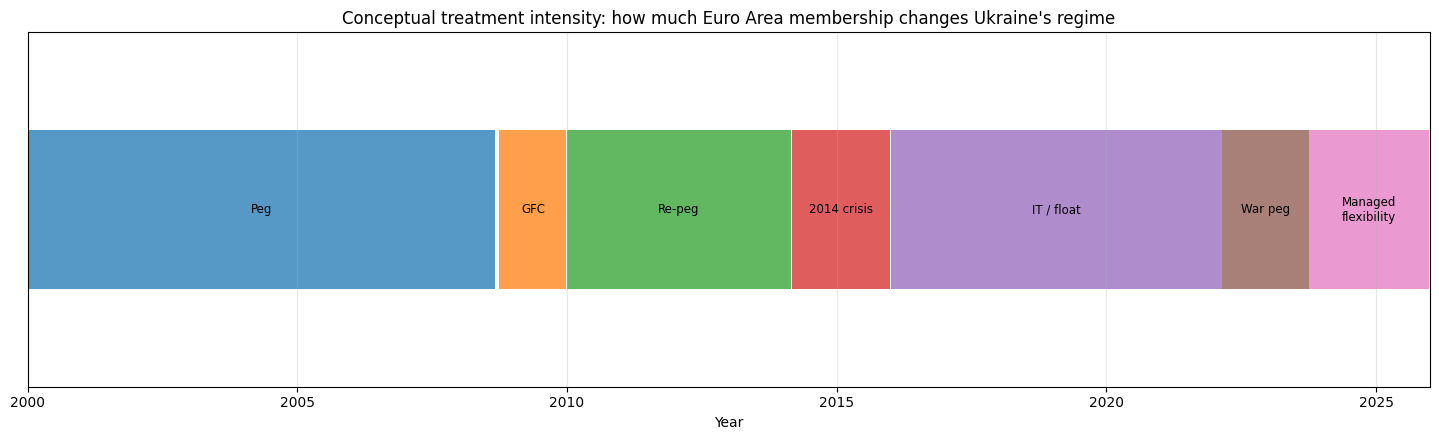

In [84]:
intensity_plot = pd.DataFrame({
    "Start": [2000.0, 2008.75, 2010.0, 2014.17, 2016.0, 2022.15, 2023.76],
    "End": [2008.67, 2009.99, 2014.16, 2015.99, 2022.14, 2023.75, 2025.99],
    "Treatment intensity": [0.25, 0.80, 0.25, 1.00, 0.65, 0.35, 0.55],
    "Label": ["Peg", "GFC", "Re-peg", "2014 crisis", "IT / float", "War peg", "Managed\nflexibility"]
})
fig, ax = plt.subplots(figsize=(14.5, 4.5))
for _, row in intensity_plot.iterrows():
    ax.barh("Euro-area treatment intensity", row["End"] - row["Start"], left=row["Start"], height=0.45, alpha=0.75)
    ax.text((row["Start"] + row["End"]) / 2, 0, row["Label"], ha="center", va="center", fontsize=8.5)
ax.set_xlim(2000, 2026)
ax.set_ylim(-0.5, 0.5)
ax.set_yticks([])
ax.set_xlabel("Year")
ax.set_title("Conceptual treatment intensity: how much Euro Area membership changes Ukraine's regime")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "partA_treatment_intensity_index.png", dpi=300, bbox_inches="tight")
plt.show()


## 10. Assessment of genuine monetary sovereignty

Ukraine's effective monetary sovereignty varied substantially over time.

During **2000–2008**, **2010–early 2014**, and **February 2022–October 2023**, Ukraine's monetary policy was heavily constrained by exchange-rate objectives. In these periods, the NBU either maintained a de facto dollar peg or a formal wartime peg. The exchange rate acted as the nominal anchor, leaving limited room for independent monetary policy.

During **2008–2009** and **2014–2015**, Ukraine recovered monetary autonomy only through crisis-driven devaluation. These were not smooth floating regimes: they were episodes of forced adjustment after external financing conditions deteriorated and reserves came under pressure.

During **2016–February 2022**, Ukraine had the strongest case for genuine monetary sovereignty. The NBU operated under inflation targeting, used the key policy rate as the main instrument, and allowed more exchange-rate flexibility. However, this autonomy remained conditional on macro-financial stability and was suspended at the start of the full-scale invasion.

Therefore, the counterfactual of Euro Area membership should not be interpreted as “Ukraine loses monetary sovereignty” uniformly across the sample. Rather, it should be interpreted as a modest regime change during de facto peg periods, a large regime change during devaluation episodes, a credibility-import effect during the pre-2016 low-credibility period, a loss of independent inflation-targeting policy during the post-2016 period, and a different crisis regime in 2022.


## 11. Direct implications for our counterfactual analysis

Part A imposes four restrictions on the counterfactual design.

1. **The counterfactual cannot be a simple Euro Area average.** Ukraine's regime history implies that the counterfactual must account for asymmetric shocks, credibility, and the loss of exchange-rate adjustment.

2. **The treatment must be time-varying.** During peg periods, Euro Area membership is a smaller monetary-regime shock because Ukraine was already using an external nominal anchor. During devaluation and inflation-targeting periods, the treatment is stronger.

3. **The model should distinguish common European inflation from Ukraine-specific shocks.** The Euro Area counterfactual should preserve exposure to common inflation forces while removing or transforming the domestic monetary/exchange-rate component.

4. **The interpretation must not reduce Euro membership to “lower inflation”.** In crisis periods, euro membership would likely have replaced currency crises with internal devaluation, sovereign fragility, or fiscal-adjustment pressure.

This motivates the preferred Part B strategy: estimate Ukrainian inflation dynamics using a semi-structural dynamic model, identify the component associated with domestic exchange-rate shocks, and attenuate that component according to the Part-A treatment-intensity index. The exercise therefore asks not whether Ukraine would mechanically have had the inflation of France or Germany, but how inflation would have evolved if the hryvnia-devaluation channel had been constrained by monetary union while common European inflation pressures remained active.

## 12. References used for Part A

### Institutional sources

- National Bank of Ukraine, **Developer API**: official hryvnia exchange-rate API and documentation. URL: `https://bank.gov.ua/en/open-data/api-dev`
- National Bank of Ukraine, **Official Exchange Rates**. URL: `https://bank.gov.ua/en/markets/exchangerates`
- National Bank of Ukraine, **Inflation and the NBU's Inflation Targets**. URL: `https://bank.gov.ua/en/monetary/about/targets/target-k`
- National Bank of Ukraine, **Monetary Policy Guidelines for 2016–2020 / Strategy document**, 17 August 2015. URL: `https://bank.gov.ua/admin_uploads/article/Strategy_v11_17_08_2015_ENG.pdf`
- National Bank of Ukraine, **FX restrictions and exchange rate policy**. URL: `https://bank.gov.ua/en/markets/liberalization`
- National Bank of Ukraine, **Currency Liberalization before 24 February 2022**. URL: `https://bank.gov.ua/en/markets/liberalization/old-liberalization`
- National Bank of Ukraine, **NBU fixes official UAH/USD exchange rate at 36.5686**, 21 July 2022. URL: `https://bank.gov.ua/en/news/all/nbu-zafiksuvav-ofitsiyniy-kurs-grivni-do-dolara-ssha-na-novomu-rivni-ta-vjiv-nizku-dodatkovih-zahodiv-dlya-zbalansuvannya-valyutnogo-rinku-ta-pidtrimannya-stiykosti-ekonomiki-v-umovah-viyni`
- National Bank of Ukraine, **NBU introduces managed flexibility of exchange rate**, 2 October 2023. URL: `https://bank.gov.ua/en/news/all/nbu-vprovadjuye-kerovanu-gnuchkist-obminnogo-kursu-scho-posilit-stiykist-valyutnogo-rinku-ta-ekonomiki`
- IMF, **Annual Report on Exchange Arrangements and Exchange Restrictions (AREAER)** database and annual reports. URL: `https://www.elibrary-areaer.imf.org/`
- IMF, **Ukraine: 2008 Article IV Consultation**, Country Report No. 08/227. URL: `https://www.imf.org/external/pubs/ft/scr/2008/cr08227.pdf`
- IMF, **Ukraine: Request for Stand-By Arrangement**, Country Report No. 14/106, 2014. URL: `https://www.imf.org/external/pubs/ft/scr/2014/cr14106.pdf`
- IMF, **Ukraine: Extended Fund Facility**, Country Report No. 15/69, 2015. URL: `https://www.imf.org/external/pubs/ft/scr/2015/cr1569.pdf`
- IMF, **Ukraine: 2023 Article IV Consultation and Second Review under the EFF**, Country Report No. 23/399. URL: `https://www.imf.org/-/media/files/publications/cr/2023/english/1ukrea2023003.pdf`

### Academic references

- Calvo, G. A., and Reinhart, C. M. (2002). “Fear of Floating.” *Quarterly Journal of Economics*, 117(2), 379–408.
- Mundell, R. A. (1961). “A Theory of Optimum Currency Areas.” *American Economic Review*, 51(4), 657–665.
- McKinnon, R. I. (1963). “Optimum Currency Areas.” *American Economic Review*, 53(4), 717–725.
- Kenen, P. B. (1969). “The Theory of Optimum Currency Areas: An Eclectic View.” In *Monetary Problems of the International Economy*.
- Barro, R. J., and Gordon, D. B. (1983). “Rules, Discretion and Reputation in a Model of Monetary Policy.” *Journal of Monetary Economics*, 12(1), 101–121.
- Giavazzi, F., and Pagano, M. (1988). “The Advantage of Tying One’s Hands.” *European Economic Review*, 32(5), 1055–1075.
- De Grauwe, P. (2012). “The Governance of a Fragile Eurozone.” *Australian Economic Review*, 45(3), 255–268.



# Part B - Counterfactual Inflation Analysis

This section constructs the counterfactual inflation series requested in the exam: **what Ukraine's year-on-year inflation might have looked like if Ukraine had been part of the Euro Area**.

The identification strategy follows directly from Part A. Euro Area membership is modelled as a **time-varying treatment** rather than a one-off constant treatment:

1. **During de facto peg periods**, Ukraine already had limited monetary sovereignty. Euro membership therefore represents a smaller monetary-regime change.
2. **During devaluation / managed-float periods**, Ukraine used exchange-rate adjustment and monetary autonomy. Euro membership represents a larger treatment because the hryvnia depreciation channel would not exist.
3. **After the transition to inflation targeting**, the NBU partially converged toward a modern central-bank regime, so imported ECB credibility should matter but less mechanically than before 2016.

Econometrically, the notebook uses a **two-layer identification strategy**. First, the main monthly counterfactual is built with a factor-augmented dynamic local-projection / ARDL framework. The Euro Area nominal anchor is estimated as a common inflation factor extracted from the HICP panel, not imposed as a simple cross-sectional average. The exchange-rate pass-through channel is then attenuated according to the Part-A treatment-intensity index.

Second, to match the structural logic of Bayoumi and Eichengreen (1993) and Blanchard and Quah (1989), the notebook adds a **structural VAR benchmark**. In that benchmark, annual output-growth and inflation dynamics are decomposed into supply and demand shocks under a long-run restriction; the counterfactual keeps Ukrainian supply shocks but replaces Ukrainian demand shocks with Euro Area demand shocks.

A final robustness exercise constructs an alternative Euro Area anchor using a simple Pioneer Detection Method (PDM)-inspired weighting scheme.



## B.1 Data sources and reproducibility

The notebook uses three types of data:

1. **Repository data** from the course GitHub repository:
   - `data_ecb_hicp_panel.csv`: monthly year-on-year HICP inflation for 11 Euro Area countries.
   - `data_ukraine_cpi_raw.csv`: monthly Ukrainian CPI raw series, expressed as previous-month base index. It must be transformed into a price-level index and then into year-on-year inflation.

2. **External mandatory data**:
   - official UAH/USD exchange rate from the National Bank of Ukraine API, already downloaded and cleaned in Part A.

3. **Additional external control**:
   - Brent crude oil price from FRED, used as a global energy-price control. If the FRED download is unavailable, the model still runs using the NBU exchange-rate data as the mandatory external macro series.

All data are either downloaded programmatically or saved into the local `data/` folder by the notebook.


In [85]:
# ============================================================
# Dependency installation (run once in a fresh environment)
# ============================================================

# This cell ensures that the notebook can run on a fresh Jupyter/Colab setup.
# It is safe to re-run: pip will simply report packages as already installed.

%pip install -q pandas numpy matplotlib requests statsmodels scikit-learn openpyxl


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: /usr/local/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [86]:

# ============================================================
# B.1 Setup for Part B
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
from pathlib import Path
import warnings

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

Path("data").mkdir(exist_ok=True)
Path("figures").mkdir(exist_ok=True)
Path("outputs").mkdir(exist_ok=True)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

BASE_RAW = "https://raw.githubusercontent.com/skimeur/pioneer-detection-method/main"
ECB_HICP_URL = f"{BASE_RAW}/data_ecb_hicp_panel.csv"
UKR_CPI_URL = f"{BASE_RAW}/data_ukraine_cpi_raw.csv"
PDM_URL = f"{BASE_RAW}/pdm.py"

print("Part B environment ready.")


Part B environment ready.


In [87]:
# ============================================================
# B.2 Helper functions: download, robust date/value parsing
# ============================================================

import re

def download_csv(url, local_path, force=False):
    """Download a CSV file if it is not already available locally."""
    local_path = Path(local_path)
    if local_path.exists() and not force:
        print(f"Using local file: {local_path}")
        return local_path
    print(f"Downloading: {url}")
    r = requests.get(url, timeout=90)
    r.raise_for_status()
    local_path.write_bytes(r.content)
    print(f"Saved to: {local_path}")
    return local_path


def read_csv_flexible(path_or_url):
    """Read CSV with delimiter detection and robust encoding fallback."""
    try:
        return pd.read_csv(path_or_url, sep=None, engine="python")
    except Exception:
        try:
            return pd.read_csv(path_or_url)
        except UnicodeDecodeError:
            return pd.read_csv(path_or_url, encoding="latin1")


def parse_monthly_period(x):
    """Parse monthly date strings robustly.

    This is crucial for the repository data, because SDMX monthly periods are
    often encoded as 'YYYY-M01'. Pandas can misread '2000-M01' as
    '2000-01-01 00:00:01', which collapses all months of a given year into
    January. This parser explicitly maps 'YYYY-Mmm' to the correct month start.
    """
    if pd.isna(x):
        return pd.NaT

    s = str(x).strip()

    # SDMX-style monthly period: 2000-M01, 2025-M12, 2000M01
    m = re.match(r"^(\d{4})[-_\s]?M(\d{1,2})$", s, flags=re.IGNORECASE)
    if m:
        year = int(m.group(1))
        month = int(m.group(2))
        if 1 <= month <= 12:
            return pd.Timestamp(year=year, month=month, day=1)
        return pd.NaT

    # Standard year-month: 2000-01, 2000/01, 2000_01
    m = re.match(r"^(\d{4})[-_/](\d{1,2})(?:[-_/]\d{1,2})?$", s)
    if m:
        year = int(m.group(1))
        month = int(m.group(2))
        if 1 <= month <= 12:
            return pd.Timestamp(year=year, month=month, day=1)
        return pd.NaT

    # Compact format: 200001
    m = re.match(r"^(\d{4})(\d{2})$", s)
    if m:
        year = int(m.group(1))
        month = int(m.group(2))
        if 1 <= month <= 12:
            return pd.Timestamp(year=year, month=month, day=1)
        return pd.NaT

    # Fallback for genuinely standard dates.
    dt = pd.to_datetime(s, errors="coerce")
    if pd.isna(dt):
        return pd.NaT
    return pd.Timestamp(year=dt.year, month=dt.month, day=1)


def to_month_start(s):
    """Convert a Series-like object to monthly start timestamps.

    Unlike pd.to_datetime alone, this correctly handles SDMX strings such as
    '2000-M01', which are used in the Ukraine CPI repository dataset.
    """
    return pd.Series(s).apply(parse_monthly_period).values


def find_date_column(df):
    """Find the most likely date/time column.

    The function first tests columns whose name suggests a time dimension,
    then falls back to all columns. It uses parse_monthly_period rather than
    raw pd.to_datetime to correctly parse SDMX TIME_PERIOD fields.
    """
    candidates = []
    for c in df.columns:
        lc = str(c).lower()
        if any(k in lc for k in ["date", "time", "period", "month"]):
            candidates.append(c)

    for c in candidates + list(df.columns):
        parsed = pd.Series(df[c]).apply(parse_monthly_period)
        if parsed.notna().mean() > 0.60:
            return c

    raise ValueError("No usable date column found. Please inspect df.columns.")

print("Helper functions loaded with robust SDMX monthly-period parsing.")


Helper functions loaded with robust SDMX monthly-period parsing.



## B.2 Repository data loading

The next cells download the two mandatory repository datasets and convert them into a common monthly format.

The most important transformation is for Ukraine: the raw CPI is a **previous-month index**. The notebook reconstructs a cumulative price-level index and then computes:

`Ukraine YoY inflation = 100 × (CPI level_t / CPI level_{t-12} − 1)`


In [88]:

# ============================================================
# B.2.1 Download mandatory repository datasets
# ============================================================

ecb_path = download_csv(ECB_HICP_URL, "data/data_ecb_hicp_panel.csv")
ukr_path = download_csv(UKR_CPI_URL, "data/data_ukraine_cpi_raw.csv")

raw_ea = read_csv_flexible(ecb_path)
raw_ukr = read_csv_flexible(ukr_path)

print("Euro Area HICP raw shape:", raw_ea.shape)
display(raw_ea.head())
print("Ukraine CPI raw shape:", raw_ukr.shape)
display(raw_ukr.head())


Using local file: data/data_ecb_hicp_panel.csv
Using local file: data/data_ukraine_cpi_raw.csv
Euro Area HICP raw shape: (312, 12)


,TIME_PERIOD,AT,BE,DE,ES,FI,FR,GR,IE,IT,NL,PT
0,2000-01-01,1.4,0.3,1.7,2.9,2.3,1.7,2.3,4.5,2.2,1.6,1.9
1,2000-02-01,1.9,2.1,1.7,3.0,2.7,1.4,2.6,4.6,2.4,1.5,1.6
2,2000-03-01,1.9,2.5,1.4,3.0,3.2,1.6,2.8,5.0,2.5,1.6,1.4
3,2000-04-01,1.8,2.3,1.0,3.0,2.5,1.3,2.1,5.1,2.4,1.7,1.9
4,2000-05-01,1.6,2.4,0.8,3.2,2.7,1.5,2.6,5.1,2.5,2.0,2.4


Ukraine CPI raw shape: (312, 26)


,Unnamed: 0,STRUCTURE[;],STRUCTURE_ID,ACTION,INDICATOR,BASE_PERIOD,REGION,GOODS_SERVICES_TYPE,FREQ,TIME_PERIOD,OBS_VALUE,UNITS_OF_MEASURE,SCALE,DECIMALS_DISPLAYED,OBS_FLAG,DSS_CODE,UPDATED,NEXT_UPDATE,NOTES_DS,NOTES_TS,NOTES_OBS,TERRITORIAL_COVERAGE,FREQUENCIES,DSS_TYPE,DYNAMICS,MAIN_INDICATORS
0,0,dataflow,SSSU:DF_PRICE_CHANGE_CONSUMER_GOODS_SERVICE(27.0.0),R,INDEX_CONSUMPRICE,PREV_MONTH,UA00000000000000000,0,M,2000-M01,104.6,1010,0,1,NaN,2.06.01.01,13.03.2026,09.04.2026,1. Note: calculations were made in accordance with the Methodological provisions of the state statistical monitoring...,1. From year 1991. 2. Consumer price indices to the corresponding period of the previous year are calculated for the...,NaN,"Ukraine, regions",monthly,discontinuous selective,information is available since 1991,consumer price indices; core inflation; average consumer prices for goods (services)
1,1,dataflow,SSSU:DF_PRICE_CHANGE_CONSUMER_GOODS_SERVICE(27.0.0),R,INDEX_CONSUMPRICE,PREV_MONTH,UA00000000000000000,0,M,2000-M02,103.3,1010,0,1,NaN,2.06.01.01,13.03.2026,09.04.2026,1. Note: calculations were made in accordance with the Methodological provisions of the state statistical monitoring...,1. From year 1991. 2. Consumer price indices to the corresponding period of the previous year are calculated for the...,NaN,"Ukraine, regions",monthly,discontinuous selective,information is available since 1991,consumer price indices; core inflation; average consumer prices for goods (services)
2,2,dataflow,SSSU:DF_PRICE_CHANGE_CONSUMER_GOODS_SERVICE(27.0.0),R,INDEX_CONSUMPRICE,PREV_MONTH,UA00000000000000000,0,M,2000-M03,102.0,1010,0,1,NaN,2.06.01.01,13.03.2026,09.04.2026,1. Note: calculations were made in accordance with the Methodological provisions of the state statistical monitoring...,1. From year 1991. 2. Consumer price indices to the corresponding period of the previous year are calculated for the...,NaN,"Ukraine, regions",monthly,discontinuous selective,information is available since 1991,consumer price indices; core inflation; average consumer prices for goods (services)
3,3,dataflow,SSSU:DF_PRICE_CHANGE_CONSUMER_GOODS_SERVICE(27.0.0),R,INDEX_CONSUMPRICE,PREV_MONTH,UA00000000000000000,0,M,2000-M04,101.7,1010,0,1,NaN,2.06.01.01,13.03.2026,09.04.2026,1. Note: calculations were made in accordance with the Methodological provisions of the state statistical monitoring...,1. From year 1991. 2. Consumer price indices to the corresponding period of the previous year are calculated for the...,NaN,"Ukraine, regions",monthly,discontinuous selective,information is available since 1991,consumer price indices; core inflation; average consumer prices for goods (services)
4,4,dataflow,SSSU:DF_PRICE_CHANGE_CONSUMER_GOODS_SERVICE(27.0.0),R,INDEX_CONSUMPRICE,PREV_MONTH,UA00000000000000000,0,M,2000-M05,102.1,1010,0,1,NaN,2.06.01.01,13.03.2026,09.04.2026,1. Note: calculations were made in accordance with the Methodological provisions of the state statistical monitoring...,1. From year 1991. 2. Consumer price indices to the corresponding period of the previous year are calculated for the...,NaN,"Ukraine, regions",monthly,discontinuous selective,information is available since 1991,consumer price indices; core inflation; average consumer prices for goods (services)


In [89]:

# ============================================================
# B.2.2 Clean Euro Area HICP panel
# ============================================================

def clean_ea_hicp(raw):
    df = raw.copy()
    date_col = find_date_column(df)
    df["date"] = to_month_start(df[date_col])
    df = df.dropna(subset=["date"])

    # Case 1: long format with country/geo and value columns
    lower_cols = {str(c).lower(): c for c in df.columns}
    geo_candidates = [c for c in df.columns if str(c).lower() in ["geo", "country", "country_name", "ref_area", "area"]]
    val_candidates = [c for c in df.columns if str(c).lower() in ["value", "obs_value", "hicp", "inflation", "rate"]]

    if geo_candidates and val_candidates:
        geo_col = geo_candidates[0]
        val_col = val_candidates[0]
        out = df[["date", geo_col, val_col]].copy()
        out[val_col] = pd.to_numeric(out[val_col], errors="coerce")
        panel = out.pivot_table(index="date", columns=geo_col, values=val_col, aggfunc="mean")
    else:
        # Case 2: wide format: one date column and one column per country
        candidate_cols = [c for c in df.columns if c != date_col and c != "date"]
        wide = df[["date"] + candidate_cols].copy()
        for c in candidate_cols:
            wide[c] = pd.to_numeric(wide[c], errors="coerce")
        # Keep columns that have enough numeric observations and look like inflation rates
        keep = []
        for c in candidate_cols:
            nonmiss = wide[c].notna().sum()
            if nonmiss >= 50:
                keep.append(c)
        panel = wide.groupby("date")[keep].mean()

    # Clean panel
    panel = panel.sort_index()
    panel = panel.dropna(axis=1, thresh=int(0.70 * len(panel)))
    panel = panel.dropna(how="all")

    # Ensure numeric
    panel = panel.apply(pd.to_numeric, errors="coerce")

    if panel.shape[1] < 3:
        raise ValueError(
            "The Euro Area HICP panel has too few country columns after cleaning. "
            "Please inspect raw_ea.columns and adjust clean_ea_hicp()."
        )

    if panel.index.nunique() < 200:
        raise ValueError(
            "The Euro Area HICP panel has too few monthly dates after cleaning. "
            "This usually points to incorrect parsing of monthly TIME_PERIOD values."
        )

    return panel


ea_panel = clean_ea_hicp(raw_ea)
print("Clean Euro Area HICP panel shape:", ea_panel.shape)
display(ea_panel.head())
display(ea_panel.tail())


Clean Euro Area HICP panel shape: (312, 11)


,AT,BE,DE,ES,FI,FR,GR,IE,IT,NL,PT
date,,,,,,,,,,,
2000-01-01,1.4,0.3,1.7,2.9,2.3,1.7,2.3,4.5,2.2,1.6,1.9
2000-02-01,1.9,2.1,1.7,3.0,2.7,1.4,2.6,4.6,2.4,1.5,1.6
2000-03-01,1.9,2.5,1.4,3.0,3.2,1.6,2.8,5.0,2.5,1.6,1.4
2000-04-01,1.8,2.3,1.0,3.0,2.5,1.3,2.1,5.1,2.4,1.7,1.9
2000-05-01,1.6,2.4,0.8,3.2,2.7,1.5,2.6,5.1,2.5,2.0,2.4


,AT,BE,DE,ES,FI,FR,GR,IE,IT,NL,PT
date,,,,,,,,,,,
2025-08-01,4.1,2.6,2.1,2.7,2.2,0.8,3.1,1.9,1.6,2.4,2.5
2025-09-01,3.9,2.7,2.4,3.0,2.2,1.1,1.8,2.7,1.8,3.0,1.9
2025-10-01,4.0,2.5,2.3,3.2,1.4,0.8,1.6,2.8,1.3,3.0,2.0
2025-11-01,4.0,2.6,2.6,3.2,1.5,0.8,2.8,3.1,1.1,2.6,2.1
2025-12-01,3.8,2.2,2.0,3.0,1.7,0.7,2.9,2.7,1.2,2.5,2.4


In [90]:

# ============================================================
# B.2.3 Clean Ukrainian CPI and compute year-on-year inflation
# ============================================================

def clean_ukraine_cpi(raw):
    df = raw.copy()
    date_col = find_date_column(df)
    df["date"] = to_month_start(df[date_col])
    df = df.dropna(subset=["date"])

    # Prefer common SDMX/value column names if present
    preferred = ["OBS_VALUE", "obs_value", "value", "Value", "cpi", "CPI", "rate", "Rate"]
    value_col = None
    for c in preferred:
        if c in df.columns:
            value_col = c
            break

    if value_col is None:
        # Choose numeric column whose median is close to 100, consistent with previous-month CPI index
        numeric_cols = []
        for c in df.columns:
            if c == "date" or c == date_col:
                continue
            s = pd.to_numeric(df[c], errors="coerce")
            if s.notna().sum() >= 50:
                numeric_cols.append((c, s.notna().sum(), s.median()))
        if not numeric_cols:
            raise ValueError("No numeric CPI value column found. Please inspect raw_ukr.columns.")
        numeric_cols = sorted(numeric_cols, key=lambda x: abs(x[2] - 100) if pd.notna(x[2]) else 999)
        value_col = numeric_cols[0][0]

    out = df[["date", value_col]].copy()
    out[value_col] = pd.to_numeric(out[value_col], errors="coerce")
    out = out.dropna().groupby("date", as_index=False)[value_col].mean().sort_values("date")
    out = out.rename(columns={value_col: "cpi_mom_index"})

    # Previous-month index: 101.5 means +1.5% m/m.
    out["cpi_level"] = (out["cpi_mom_index"] / 100.0).cumprod() * 100.0
    out["pi_ukr_yoy"] = 100.0 * (out["cpi_level"] / out["cpi_level"].shift(12) - 1.0)

    out = out[["date", "cpi_mom_index", "cpi_level", "pi_ukr_yoy"]]
    return out

ukr_cpi = clean_ukraine_cpi(raw_ukr)
print("Clean Ukraine CPI shape:", ukr_cpi.shape)
display(ukr_cpi.head(15))
display(ukr_cpi.tail())

# Quick validation
if ukr_cpi["pi_ukr_yoy"].dropna().abs().max() > 1000:
    raise ValueError("Ukraine YoY inflation looks implausibly large. Check CPI transformation.")

if ukr_cpi["date"].nunique() < 200:
    raise ValueError(
        "Ukraine CPI has too few monthly observations after cleaning. "
        "This usually means the TIME_PERIOD field was parsed incorrectly. "
        "Check that dates such as 2000-M01 are mapped to 2000-01-01, 2000-M02 to 2000-02-01, etc."
    )


Clean Ukraine CPI shape: (312, 4)


,date,cpi_mom_index,cpi_level,pi_ukr_yoy
0,2000-01-01,104.6,104.600000,NaN
1,2000-02-01,103.3,108.051800,NaN
2,2000-03-01,102.0,110.212836,NaN
3,2000-04-01,101.7,112.086454,NaN
4,2000-05-01,102.1,114.440270,NaN
5,2000-06-01,103.7,118.674560,NaN
6,2000-07-01,99.9,118.555885,NaN
7,2000-08-01,100.0,118.555885,NaN
8,2000-09-01,102.6,121.638338,NaN
9,2000-10-01,101.4,123.341275,NaN


,date,cpi_mom_index,cpi_level,pi_ukr_yoy
307,2025-08-01,99.8,1735.206994,13.212290
308,2025-09-01,100.3,1740.412615,11.873820
309,2025-10-01,100.9,1756.076329,10.884759
310,2025-11-01,100.4,1763.100634,9.252500
311,2025-12-01,100.2,1766.626835,7.959571



## B.3 External macroeconomic data

The UAH/USD series from the NBU is the main external macro variable. It is essential for identification because it captures the exchange-rate adjustment channel that would disappear under Euro Area membership.

The notebook also attempts to download Brent oil prices from FRED as a global energy-price control. This helps avoid attributing all inflation movements to the exchange rate when part of them reflect global commodity shocks.


In [91]:

# ============================================================
# B.3.1 Load NBU UAH/USD series produced in Part A
# ============================================================

nbu_monthly_path = Path("data/nbu_usd_uah_monthly.csv")

if nbu_monthly_path.exists():
    nbu_fx = pd.read_csv(nbu_monthly_path)
    nbu_fx["date"] = to_month_start(nbu_fx["date"])
else:
    # Reuse the Part-A function if the CSV has not yet been produced.
    # This requires that the Part-A cell defining download_nbu_usd_uah() has been run.
    print("NBU monthly CSV not found. Downloading through the Part-A function...")
    nbu_daily = download_nbu_usd_uah(start_year=2000, end_year=2025)
    nbu_fx = (
        nbu_daily
        .set_index("date")
        .resample("MS")["uah_per_usd"]
        .mean()
        .reset_index()
    )
    nbu_fx.to_csv(nbu_monthly_path, index=False)

nbu_fx = nbu_fx[["date", "uah_per_usd"]].sort_values("date")
nbu_fx["dep_yoy"] = 100.0 * (nbu_fx["uah_per_usd"] / nbu_fx["uah_per_usd"].shift(12) - 1.0)
nbu_fx["dep_mom"] = 100.0 * (nbu_fx["uah_per_usd"] / nbu_fx["uah_per_usd"].shift(1) - 1.0)

print("NBU FX monthly shape:", nbu_fx.shape)
display(nbu_fx.head())
display(nbu_fx.tail())


NBU FX monthly shape: (312, 4)


,date,uah_per_usd,dep_yoy,dep_mom
0,2000-01-01,5.381058,NaN,NaN
1,2000-02-01,5.543114,NaN,3.011596
2,2000-03-01,5.467974,NaN,-1.355549
3,2000-04-01,5.422750,NaN,-0.827074
4,2000-05-01,5.404077,NaN,-0.344338


,date,uah_per_usd,dep_yoy,dep_mom
307,2025-08-01,41.441897,0.613077,-0.842726
308,2025-09-01,41.318337,0.172076,-0.298153
309,2025-10-01,41.627123,0.932691,0.747334
310,2025-11-01,42.104007,1.822826,1.145609
311,2025-12-01,42.199929,1.072809,0.227822


In [92]:

# ============================================================
# B.3.2 Optional external control: Brent crude oil price from FRED
# ============================================================

FRED_BRENT_URL = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=DCOILBRENTEU"

try:
    brent_path = download_csv(FRED_BRENT_URL, "data/fred_brent_daily.csv")
    brent_raw = pd.read_csv(brent_path)
    # FRED format: DATE, DCOILBRENTEU
    date_col = find_date_column(brent_raw)
    value_cols = [c for c in brent_raw.columns if c != date_col]
    value_col = value_cols[0]
    brent_raw["date"] = pd.to_datetime(brent_raw[date_col], errors="coerce")
    brent_raw["brent"] = pd.to_numeric(brent_raw[value_col], errors="coerce")
    brent = (
        brent_raw.dropna(subset=["date", "brent"])
        .set_index("date")
        .resample("MS")["brent"]
        .mean()
        .reset_index()
    )
    brent["brent_yoy"] = 100.0 * (brent["brent"] / brent["brent"].shift(12) - 1.0)
    print("Brent data loaded:", brent.shape)
    display(brent.tail())
except Exception as e:
    print("Brent download failed. The model will run without this optional control.")
    print("Reason:", repr(e))
    brent = pd.DataFrame({"date": pd.to_datetime([]), "brent": [], "brent_yoy": []})


Downloading: https://fred.stlouisfed.org/graph/fredgraph.csv?id=DCOILBRENTEU
Brent download failed. The model will run without this optional control.
Reason: HTTPError('504 Server Error: Gateway Time-out for url: https://fred.stlouisfed.org/graph/fredgraph.csv?id=DCOILBRENTEU')


## B.4 Euro Area common inflation factor

The Euro Area counterfactual anchor is not a simple average. The notebook estimates a common inflation factor from the cross-country HICP panel using principal components, following the logic of common inflation-factor approaches.

The first principal component is rescaled into inflation units and oriented so that it is positively correlated with the cross-sectional Euro Area HICP mean.

The cross-country mean is shown only as a visual benchmark. If the PCA factor closely tracks it, this should be interpreted as evidence that the Euro Area panel contains a strong common inflation cycle, not as evidence that the counterfactual simply imposes an arithmetic average.

First common inflation factor explains 80.2% of standardized panel variance.


,date,ea_factor,ea_mean
0,2000-01-01,2.046778,2.072727
1,2000-02-01,2.272239,2.318182
2,2000-03-01,2.398852,2.445455
3,2000-04-01,2.218678,2.281818
4,2000-05-01,2.368530,2.436364


,date,ea_factor,ea_mean
307,2025-08-01,2.314623,2.363636
308,2025-09-01,2.377999,2.409091
309,2025-10-01,2.206954,2.263636
310,2025-11-01,2.323780,2.400000
311,2025-12-01,2.207308,2.281818


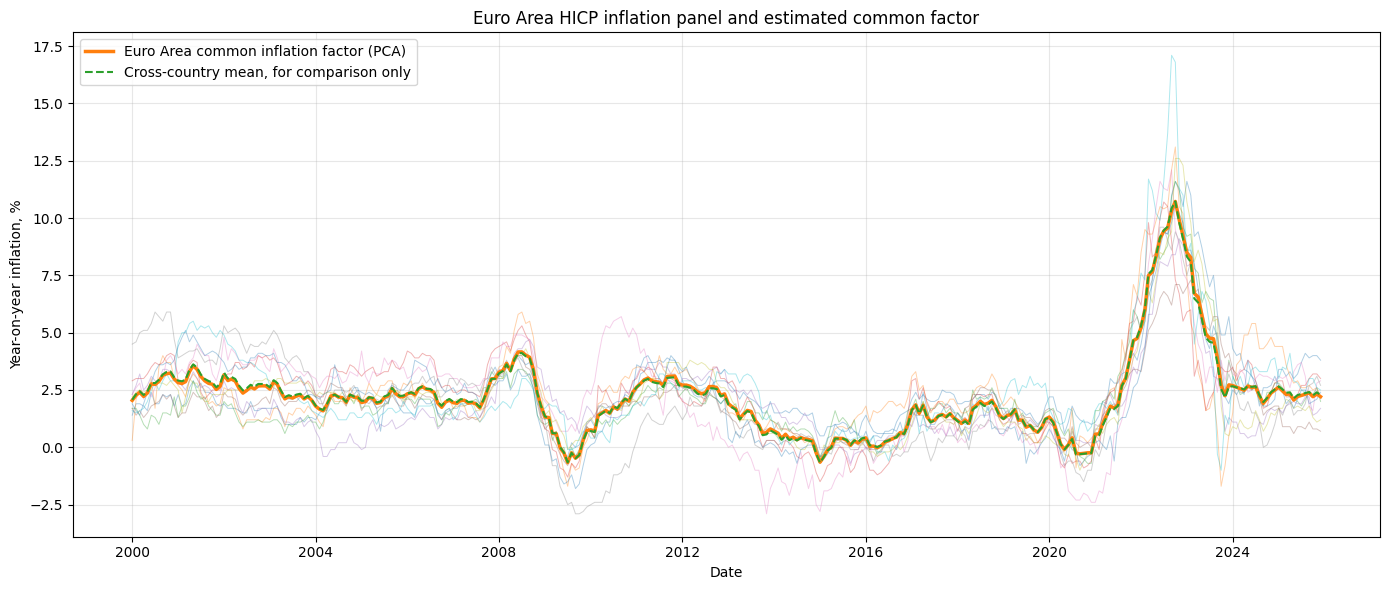

In [93]:

# ============================================================
# B.4 Common Euro Area inflation factor via PCA
# ============================================================

# Align panel and fill small gaps by interpolation.
ea_for_pca = ea_panel.copy().sort_index()
ea_for_pca = ea_for_pca.interpolate(limit_direction="both")

# Standardize and extract first principal component
scaler = StandardScaler()
Z = scaler.fit_transform(ea_for_pca.values)
pc1 = PCA(n_components=1).fit_transform(Z).ravel()

ea_mean = ea_for_pca.mean(axis=1)
if np.corrcoef(pc1, ea_mean.values)[0, 1] < 0:
    pc1 = -pc1

# Rescale PC1 into inflation-rate units
pc1_scaled = (pc1 - pc1.mean()) / pc1.std() * ea_mean.std() + ea_mean.mean()

ea_factor = pd.DataFrame({
    "date": ea_for_pca.index,
    "ea_factor": pc1_scaled,
    "ea_mean": ea_mean.values
})

# Share of variance explained
pca_full = PCA().fit(Z)
var_explained_1 = pca_full.explained_variance_ratio_[0]
print(f"First common inflation factor explains {var_explained_1:.1%} of standardized panel variance.")

display(ea_factor.head())
display(ea_factor.tail())

# Plot panel and common factor
fig, ax = plt.subplots(figsize=(14, 6))
for c in ea_for_pca.columns:
    ax.plot(ea_for_pca.index, ea_for_pca[c], linewidth=0.7, alpha=0.35)
ax.plot(ea_factor["date"], ea_factor["ea_factor"], linewidth=2.5, label="Euro Area common inflation factor (PCA)")
ax.plot(ea_factor["date"], ea_factor["ea_mean"], linewidth=1.5, linestyle="--", label="Cross-country mean, for comparison only")
ax.set_title("Euro Area HICP inflation panel and estimated common factor")
ax.set_xlabel("Date")
ax.set_ylabel("Year-on-year inflation, %")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figures/ea_common_inflation_factor.png", dpi=300)
plt.show()


 The first principal component captures a clear common Euro Area inflation cycle. Its close comovement with the cross-country mean is not a weakness of the approach; rather, it indicates that a large share of Euro Area inflation dynamics is driven by a common component. The counterfactual nevertheless does not mechanically impose a simple average: the Euro Area anchor is extracted from the covariance structure of the panel and embedded in a dynamic model of Ukrainian inflation.


## B.5 Treatment intensity from Part A

The treatment-intensity index translates the Part-A monetary-regime chronology into the empirical counterfactual.

- Low values mean Euro Area membership would not have changed much because Ukraine was already constrained by a peg.
- High values mean Euro Area membership would have substantially changed the adjustment mechanism by removing the hryvnia-devaluation channel.

This is the key bridge between Part A and Part B.


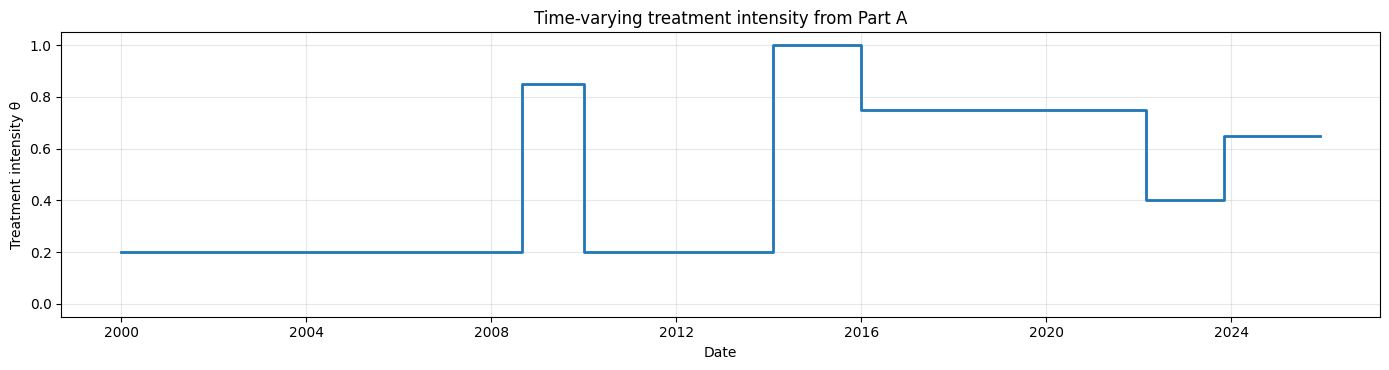

In [94]:

# ============================================================
# B.5 Treatment intensity index from Part A
# ============================================================

def treatment_theta(date):
    """Map a date to the Part-A treatment-intensity index."""
    d = pd.to_datetime(date)
    if d < pd.Timestamp("2008-09-01"):
        return 0.20  # de facto USD peg: small additional treatment
    elif d < pd.Timestamp("2010-01-01"):
        return 0.85  # peg break and GFC adjustment
    elif d < pd.Timestamp("2014-02-01"):
        return 0.20  # renewed peg/stabilized arrangement
    elif d < pd.Timestamp("2016-01-01"):
        return 1.00  # major devaluation and regime break
    elif d < pd.Timestamp("2022-02-24"):
        return 0.75  # inflation targeting / managed float
    elif d < pd.Timestamp("2023-10-03"):
        return 0.40  # wartime fixed rate and capital controls
    else:
        return 0.65  # managed flexibility

# Create monthly index spanning the available sample
all_months = pd.DataFrame({"date": pd.date_range("2000-01-01", "2025-12-01", freq="MS")})
all_months["theta"] = all_months["date"].apply(treatment_theta)

fig, ax = plt.subplots(figsize=(14, 3.8))
ax.step(all_months["date"], all_months["theta"], where="post", linewidth=2)
ax.set_title("Time-varying treatment intensity from Part A")
ax.set_xlabel("Date")
ax.set_ylabel("Treatment intensity θ")
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figures/treatment_intensity_partB.png", dpi=300)
plt.show()


 The wartime period receives a lower treatment intensity than the 2014–2015 floating crisis because the NBU temporarily reintroduced a fixed exchange rate and extensive restrictions. This does not mean that Euro Area membership would have been irrelevant in 2022; it means that the specific exchange-rate-sovereignty channel modelled here was less active once the hryvnia was administratively fixed.


## B.6 Merge final modelling dataset

The final monthly dataset contains:

- Ukrainian year-on-year inflation;
- Euro Area common inflation factor;
- UAH/USD depreciation;
- treatment intensity;
- optional Brent oil-price growth control.


In [95]:
# ============================================================
# B.6 Merge final dataset
# ============================================================

# Merge the mandatory repository data with the external macro variables.
df = ukr_cpi.merge(ea_factor, on="date", how="inner")
df = df.merge(nbu_fx[["date", "uah_per_usd", "dep_yoy", "dep_mom"]], on="date", how="left")
df = df.merge(all_months, on="date", how="left")

if not brent.empty:
    df = df.merge(brent[["date", "brent", "brent_yoy"]], on="date", how="left")
else:
    df["brent"] = np.nan
    df["brent_yoy"] = np.nan

# Ensure chronological order and numeric types.
df = df.sort_values("date").reset_index(drop=True)
for col in ["pi_ukr_yoy", "ea_factor", "ea_mean", "uah_per_usd", "dep_yoy", "dep_mom", "theta", "brent", "brent_yoy"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# The first 12 months of year-on-year depreciation are mechanically missing.
# For modelling, interpolate isolated FX gaps, but do not invent the initial 12-month YoY history.
df["dep_yoy"] = df["dep_yoy"].interpolate(limit_direction="both")
df["dep_mom"] = df["dep_mom"].interpolate(limit_direction="both")

# Replace missing Brent YoY with zero only after adding an availability flag.
# This keeps the model reproducible even when FRED is temporarily unreachable.
df["has_brent"] = df["brent_yoy"].notna().astype(int)
df["brent_yoy_filled"] = df["brent_yoy"].fillna(0.0)

# Keep only rows where the two core inflation series are available.
df = df.dropna(subset=["pi_ukr_yoy", "ea_factor"]).reset_index(drop=True)

print("Final modelling dataset shape:", df.shape)
print("Date range:", df["date"].min().date(), "to", df["date"].max().date())
print("Non-missing observations by key variable:")
display(df[["pi_ukr_yoy", "ea_factor", "dep_yoy", "brent_yoy_filled", "theta"]].notna().sum().to_frame("non_missing"))

display(df.head(15))
display(df.tail())

# Save modelling dataset
output_path = "outputs/modelling_dataset_partB.csv"
df.to_csv(output_path, index=False)
print(f"Saved modelling dataset to {output_path}")


Final modelling dataset shape: (300, 14)
Date range: 2001-01-01 to 2025-12-01
Non-missing observations by key variable:


,non_missing
pi_ukr_yoy,300
ea_factor,300
dep_yoy,300
brent_yoy_filled,300
theta,300


,date,cpi_mom_index,cpi_level,pi_ukr_yoy,ea_factor,ea_mean,uah_per_usd,dep_yoy,dep_mom,theta,brent,brent_yoy,has_brent,brent_yoy_filled
0,2001-01-01,101.5,127.703234,22.087222,2.817837,2.909091,5.433087,0.966892,-0.050561,0.2,NaN,NaN,0,0.0
1,2001-02-01,100.6,128.469454,18.896172,2.784901,2.881818,5.429554,-2.048672,-0.065037,0.2,NaN,NaN,0,0.0
2,2001-03-01,100.6,129.240270,17.264263,2.862405,2.954545,5.421368,-0.852353,-0.150764,0.2,NaN,NaN,0,0.0
3,2001-04-01,101.5,131.178874,17.033655,3.295857,3.372727,5.418180,-0.084275,-0.058800,0.2,NaN,NaN,0,0.0
4,2001-05-01,100.4,131.703590,15.085005,3.566337,3.618182,5.413694,0.177942,-0.082804,0.2,NaN,NaN,0,0.0
5,2001-06-01,100.6,132.493811,11.644662,3.393080,3.472727,5.401240,-0.640172,-0.230038,0.2,NaN,NaN,0,0.0
6,2001-07-01,98.3,130.241417,9.856560,3.090438,3.172727,5.371148,-1.239594,-0.557124,0.2,NaN,NaN,0,0.0
7,2001-08-01,99.8,129.980934,9.636846,2.902181,2.981818,5.346665,-1.687860,-0.455841,0.2,NaN,NaN,0,0.0
8,2001-09-01,100.4,130.500858,7.285959,2.789551,2.890909,5.338973,-1.839244,-0.143850,0.2,NaN,NaN,0,0.0
9,2001-10-01,100.2,130.761859,6.016303,2.749392,2.827273,5.310287,-2.361385,-0.537299,0.2,NaN,NaN,0,0.0


,date,cpi_mom_index,cpi_level,pi_ukr_yoy,ea_factor,ea_mean,uah_per_usd,dep_yoy,dep_mom,theta,brent,brent_yoy,has_brent,brent_yoy_filled
295,2025-08-01,99.8,1735.206994,13.212290,2.314623,2.363636,41.441897,0.613077,-0.842726,0.65,NaN,NaN,0,0.0
296,2025-09-01,100.3,1740.412615,11.873820,2.377999,2.409091,41.318337,0.172076,-0.298153,0.65,NaN,NaN,0,0.0
297,2025-10-01,100.9,1756.076329,10.884759,2.206954,2.263636,41.627123,0.932691,0.747334,0.65,NaN,NaN,0,0.0
298,2025-11-01,100.4,1763.100634,9.252500,2.323780,2.400000,42.104007,1.822826,1.145609,0.65,NaN,NaN,0,0.0
299,2025-12-01,100.2,1766.626835,7.959571,2.207308,2.281818,42.199929,1.072809,0.227822,0.65,NaN,NaN,0,0.0


Saved modelling dataset to outputs/modelling_dataset_partB.csv


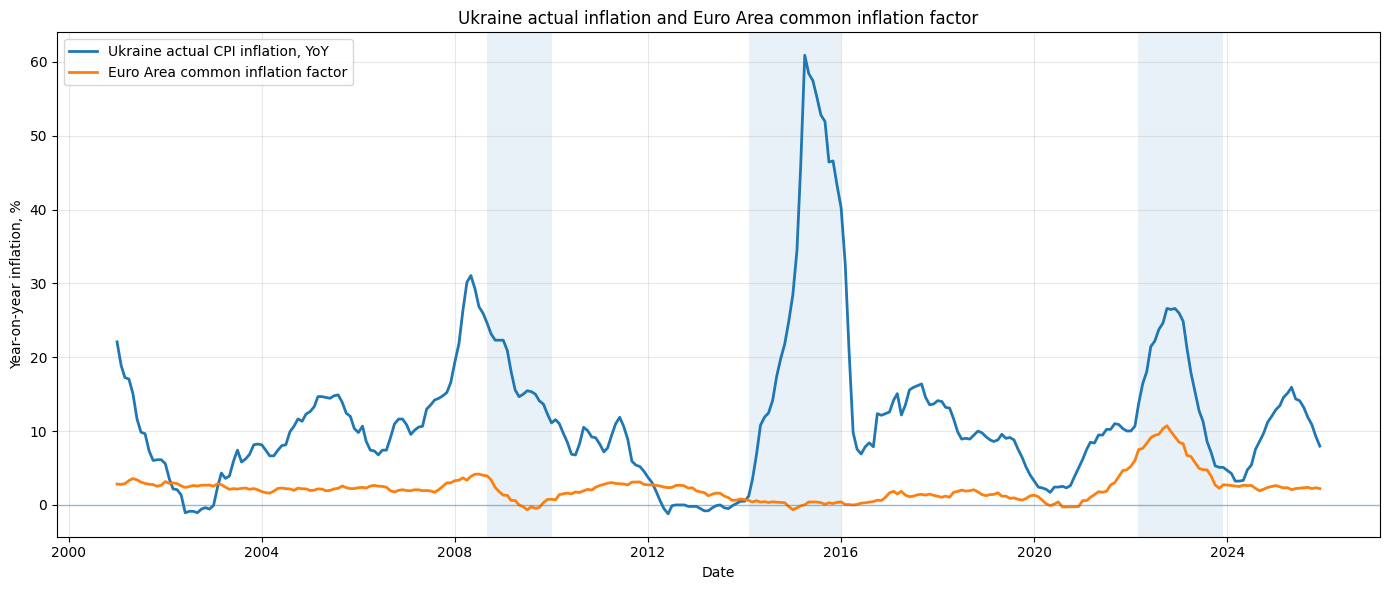

In [96]:

# ============================================================
# B.6.1 Descriptive figure: actual Ukraine inflation vs EA anchor
# ============================================================

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df["date"], df["pi_ukr_yoy"], linewidth=2.0, label="Ukraine actual CPI inflation, YoY")
ax.plot(df["date"], df["ea_factor"], linewidth=2.0, label="Euro Area common inflation factor")
ax.axhline(0, linewidth=1, alpha=0.4)

for label, start, end in [
    ("GFC", "2008-09-01", "2010-01-01"),
    ("Crimea/Donbas", "2014-02-01", "2016-01-01"),
    ("Full-scale invasion", "2022-02-24", "2023-12-01"),
]:
    ax.axvspan(pd.to_datetime(start), pd.to_datetime(end), alpha=0.10)

ax.set_title("Ukraine actual inflation and Euro Area common inflation factor")
ax.set_xlabel("Date")
ax.set_ylabel("Year-on-year inflation, %")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figures/actual_ukraine_vs_ea_factor.png", dpi=300)
plt.show()



## B.7 Stationarity diagnostics and lag choice

The model is estimated in inflation rates and growth/depreciation rates, not price levels. This avoids estimating the counterfactual on non-stationary level variables.

The notebook reports simple ADF tests and selects the number of autoregressive lags by AIC over a small grid. The preferred specification is intentionally parsimonious because the sample is short and contains multiple regime breaks.


In [97]:

# ============================================================
# B.7 Stationarity diagnostics
# ============================================================

variables_for_adf = ["pi_ukr_yoy", "ea_factor", "dep_yoy", "brent_yoy_filled"]
adf_rows = []
for v in variables_for_adf:
    s = df[v].dropna()
    if len(s) > 30 and s.nunique() > 5:
        stat, pval, lags, nobs, *_ = adfuller(s, autolag="AIC")
        adf_rows.append({"variable": v, "ADF statistic": stat, "p-value": pval, "lags": lags, "nobs": nobs})

adf_table = pd.DataFrame(adf_rows)
display(adf_table)
adf_table.to_csv("outputs/adf_tests_partB.csv", index=False)


,variable,ADF statistic,p-value,lags,nobs
0,pi_ukr_yoy,-3.334638,0.013399,13,286
1,ea_factor,-2.574297,0.098427,12,287
2,dep_yoy,-3.364801,0.012219,12,287


In [98]:
# ============================================================
# B.7.1 Build ARDL-style design matrix and choose lag length
# ============================================================


def build_design(data, p=3, anchor_col="ea_factor", dep_col="dep_yoy", brent_col="brent_yoy_filled"):
    """Build a robust ARDL-style design matrix.

    This function is deliberately defensive: it checks required columns,
    converts variables to numeric values, and drops only the rows that are
    unusable for the selected lag order.
    """
    required = ["date", "pi_ukr_yoy", anchor_col, dep_col, brent_col]
    missing = [c for c in required if c not in data.columns]
    if missing:
        raise KeyError(f"Missing columns in modelling dataset: {missing}")

    out = data.copy().sort_values("date").reset_index(drop=True)
    out["date"] = pd.to_datetime(out["date"], errors="coerce")

    for col in ["pi_ukr_yoy", anchor_col, dep_col, brent_col]:
        out[col] = pd.to_numeric(out[col], errors="coerce")

    # Lags of Ukrainian inflation
    for lag in range(1, p + 1):
        out[f"pi_lag{lag}"] = out["pi_ukr_yoy"].shift(lag)

    # Current and lagged exchange-rate depreciation
    for lag in range(0, p + 1):
        out[f"dep_lag{lag}"] = out[dep_col].shift(lag)

    # Current and one lag of the Euro Area anchor
    out["anchor"] = out[anchor_col]
    out["anchor_lag1"] = out[anchor_col].shift(1)

    # Energy-price control
    out["brent_control"] = out[brent_col]

    xcols = [f"pi_lag{lag}" for lag in range(1, p + 1)]
    xcols += [f"dep_lag{lag}" for lag in range(0, p + 1)]
    xcols += ["anchor", "anchor_lag1", "brent_control"]

    model_df = out[["date", "pi_ukr_yoy"] + xcols].dropna().copy()
    X = sm.add_constant(model_df[xcols], has_constant="add")
    y = model_df["pi_ukr_yoy"]
    return model_df, y, X, xcols


def select_lag_aic(data, max_p=6, train_end="2021-12-01", anchor_col="ea_factor"):
    """Select lag length by AIC on the pre-war sample.

    The previous version required at least 60 observations for every lag.
    That can fail if the downloaded repository data are shorter than expected
    or if an optional external series has missing values. This version uses a
    sample-size rule based on the number of regressors and provides explicit
    diagnostics if no lag can be estimated.
    """
    rows = []
    diagnostics = []
    train_end = pd.to_datetime(train_end)

    for p in range(1, max_p + 1):
        model_df, y, X, xcols = build_design(data, p=p, anchor_col=anchor_col)
        train = model_df["date"] <= train_end
        n_train = int(train.sum())
        n_params = int(X.shape[1])
        min_required = max(24, n_params + 8)  # enough degrees of freedom, but not excessively strict

        diagnostics.append({
            "p": p,
            "usable_rows": int(len(model_df)),
            "prewar_rows": n_train,
            "n_parameters": n_params,
            "min_required": min_required,
        })

        if n_train < min_required:
            continue

        res = sm.OLS(y.loc[train], X.loc[train]).fit()
        rows.append({"p": p, "AIC": res.aic, "BIC": res.bic, "nobs": n_train, "n_params": n_params})

    diag_table = pd.DataFrame(diagnostics)
    display(diag_table)

    if not rows:
        print("No lag length satisfied the degrees-of-freedom rule. Trying a conservative fallback p=1 on all available pre-war data...")
        model_df, y, X, xcols = build_design(data, p=1, anchor_col=anchor_col)
        train = model_df["date"] <= train_end
        if int(train.sum()) <= X.shape[1] + 3:
            raise ValueError(
                "Lag selection failed because the modelling dataset has too few usable pre-war observations.\n"
                f"Dataset date range: {data['date'].min()} to {data['date'].max()}\n"
                f"Non-missing core variables:\n{data[['pi_ukr_yoy', anchor_col, 'dep_yoy', 'brent_yoy_filled']].notna().sum()}"
            )
        res = sm.OLS(y.loc[train], X.loc[train]).fit()
        lag_table = pd.DataFrame([{"p": 1, "AIC": res.aic, "BIC": res.bic, "nobs": int(train.sum()), "n_params": int(X.shape[1])}])
        best_p = 1
        return best_p, lag_table

    lag_table = pd.DataFrame(rows).sort_values("AIC").reset_index(drop=True)
    best_p = int(lag_table.iloc[0]["p"])
    return best_p, lag_table


best_p, lag_table = select_lag_aic(df, max_p=6, train_end="2021-12-01", anchor_col="ea_factor")
print(f"Selected lag length by pre-war AIC: p = {best_p}")
display(lag_table)
lag_table.to_csv("outputs/lag_selection_partB.csv", index=False)


,p,usable_rows,prewar_rows,n_parameters,min_required
0,1,299,251,7,24
1,2,298,250,9,24
2,3,297,249,11,24
3,4,296,248,13,24
4,5,295,247,15,24
5,6,294,246,17,25


Selected lag length by pre-war AIC: p = 6


,p,AIC,BIC,nobs,n_params
0,6,807.755109,863.840414,246,17
1,5,815.491792,864.623228,247,15
2,4,819.680254,861.841399,248,13
3,3,860.161268,895.335797,249,11
4,2,919.435921,947.607608,250,9
5,1,1023.838934,1044.991652,251,7


## B.8 Local-projection evidence on exchange-rate pass-through

Before constructing the counterfactual, the notebook estimates local projections of Ukrainian inflation on exchange-rate depreciation. This provides a transparent empirical check that hryvnia depreciation is associated with subsequent inflation dynamics.

The local projection is:

`π_{t+h} − π_{t−1} = α_h + β_h Δe_t + Γ_h controls_t + u_{t+h}`

where controls include the Euro Area inflation factor, Brent growth and lagged Ukrainian inflation.

This is not the main counterfactual model. It is a validation step: if exchange-rate pass-through is positive and persistent, then attenuating the hryvnia-depreciation channel under hypothetical Euro Area membership is economically meaningful.

,horizon,beta_dep_yoy,se,lower95,upper95,nobs
0,0,0.060293,0.014516,0.031841,0.088744,251
1,1,0.131745,0.031479,0.070045,0.193444,251
2,2,0.191373,0.046164,0.100892,0.281855,251
3,3,0.220953,0.053007,0.117059,0.324847,251
4,4,0.249145,0.061632,0.128347,0.369943,251
5,5,0.266805,0.069771,0.130054,0.403557,251
6,6,0.273876,0.077570,0.121838,0.425913,251
7,7,0.276735,0.086564,0.107069,0.446401,251
8,8,0.269632,0.093966,0.085458,0.453807,251
9,9,0.265366,0.099758,0.069841,0.460892,251


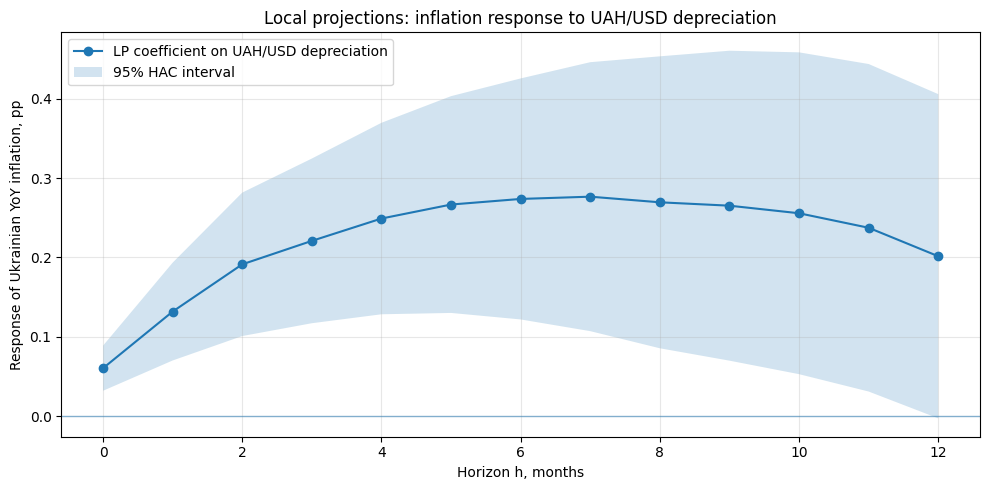

In [99]:
# ============================================================
# B.8 Local projections: inflation response to exchange-rate depreciation
# ============================================================


def estimate_local_projections(data, H=12, train_end="2021-12-01"):
    rows = []
    base = data.copy().sort_values("date").reset_index(drop=True)
    base["date"] = pd.to_datetime(base["date"], errors="coerce")
    base["pi_lag1"] = base["pi_ukr_yoy"].shift(1)

    for h in range(H + 1):
        lp = base.copy()
        lp["y_h"] = lp["pi_ukr_yoy"].shift(-h) - lp["pi_ukr_yoy"].shift(1)
        cols = ["dep_yoy", "ea_factor", "brent_yoy_filled", "pi_lag1"]
        reg = lp[["date", "y_h"] + cols].dropna()
        reg = reg[reg["date"] <= pd.to_datetime(train_end)]

        if len(reg) < max(24, len(cols) + 8):
            continue

        X = sm.add_constant(reg[cols], has_constant="add")
        y = reg["y_h"]
        res = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": min(12, h + 1)})
        beta = res.params.get("dep_yoy", np.nan)
        se = res.bse.get("dep_yoy", np.nan)
        rows.append({
            "horizon": h,
            "beta_dep_yoy": beta,
            "se": se,
            "lower95": beta - 1.96 * se,
            "upper95": beta + 1.96 * se,
            "nobs": len(reg),
        })

    return pd.DataFrame(rows)


lp_results = estimate_local_projections(df, H=12, train_end="2021-12-01")
display(lp_results)
lp_results.to_csv("outputs/local_projection_exchange_rate_passthrough.csv", index=False)

if lp_results.empty:
    print("Local projections could not be estimated because the usable pre-war sample is too short. The main ARDL counterfactual still runs.")
else:
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(lp_results["horizon"], lp_results["beta_dep_yoy"], marker="o", label="LP coefficient on UAH/USD depreciation")
    ax.fill_between(lp_results["horizon"], lp_results["lower95"], lp_results["upper95"], alpha=0.2, label="95% HAC interval")
    ax.axhline(0, linewidth=1, alpha=0.5)
    ax.set_title("Local projections: inflation response to UAH/USD depreciation")
    ax.set_xlabel("Horizon h, months")
    ax.set_ylabel("Response of Ukrainian YoY inflation, pp")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("figures/lp_exchange_rate_passthrough.png", dpi=300)
    plt.show()


A positive and persistent response of Ukrainian year-on-year inflation to UAH/USD depreciation supports the central modelling assumption of the counterfactual. The pass-through builds gradually over several months, consistent with delayed transmission from exchange-rate movements to import prices and consumer prices.


## B.9 Main econometric counterfactual

The estimated actual-data model is:

`π_UKR,t = α + ρ(L)π_UKR,t−1 + β(L)Δe_t + λ(L)F_EA,t + δ Oil_t + ε_t`

The counterfactual modifies the exchange-rate channel. Under Euro Area membership, Ukraine would not have had a hryvnia exchange rate against the dollar. Therefore, the depreciation term is attenuated by the Part-A treatment intensity:

`Δe_CF,t = (1 − θ_t) × Δe_actual,t`

- If `θ_t` is low, Ukraine was already close to an external anchor, so the counterfactual differs little from actual exchange-rate conditions.
- If `θ_t` is high, the hryvnia-devaluation channel is largely removed.

The resulting counterfactual is recursively simulated so that lagged counterfactual inflation, not actual inflation, feeds into future counterfactual values.


In [100]:
# ============================================================
# B.9 Estimate main model and construct recursive counterfactual
# ============================================================


def fit_main_model(data, p, train_end="2021-12-01", anchor_col="ea_factor"):
    model_df, y, X, xcols = build_design(data, p=p, anchor_col=anchor_col)
    train = model_df["date"] <= pd.to_datetime(train_end)

    if int(train.sum()) <= X.shape[1] + 3:
        raise ValueError(
            "The main model has too few pre-war observations for the chosen lag length. "
            "Try reducing best_p or check the merged data."
        )

    res = sm.OLS(y.loc[train], X.loc[train]).fit(cov_type="HAC", cov_kwds={"maxlags": min(12, int(train.sum() // 4))})
    return res, model_df, xcols


main_model, main_model_df, main_xcols = fit_main_model(df, best_p, train_end="2021-12-01", anchor_col="ea_factor")
print(main_model.summary())

# Save coefficient table
coef_table = pd.DataFrame({
    "coef": main_model.params,
    "std_err_HAC": main_model.bse,
    "t": main_model.tvalues,
    "p_value": main_model.pvalues,
})
display(coef_table)
coef_table.to_csv("outputs/main_model_coefficients.csv")


                            OLS Regression Results                            
Dep. Variable:             pi_ukr_yoy   R-squared:                       0.989
Model:                            OLS   Adj. R-squared:                  0.988
Method:                 Least Squares   F-statistic:                     4392.
Date:                Thu, 04 Jun 2026   Prob (F-statistic):          2.99e-273
Time:                        22:24:31   Log-Likelihood:                -387.88
No. Observations:                 246   AIC:                             807.8
Df Residuals:                     230   BIC:                             863.8
Df Model:                          15                                         
Covariance Type:                  HAC                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.1206      0.164      0.736

,coef,std_err_HAC,t,p_value
const,0.120643,0.163824,0.736420,4.614750e-01
pi_lag1,1.585510,0.085848,18.468791,3.682400e-76
pi_lag2,-0.621745,0.158800,-3.915272,9.030251e-05
pi_lag3,-0.061265,0.181368,-0.337795,7.355177e-01
pi_lag4,-0.015600,0.084200,-0.185272,8.530157e-01
pi_lag5,0.183456,0.094399,1.943417,5.196583e-02
pi_lag6,-0.125676,0.056619,-2.219688,2.643995e-02
dep_lag0,0.020228,0.009182,2.202950,2.759828e-02
dep_lag1,0.042130,0.012578,3.349514,8.095353e-04
dep_lag2,0.032453,0.018197,1.783460,7.451147e-02


In [101]:

# ============================================================
# B.9.1 Recursive simulation function
# ============================================================

def recursive_counterfactual(data, model, p, anchor_col="ea_factor"):
    """
    Recursively simulate counterfactual inflation.

    Key counterfactual restriction:
    dep_cf_t = (1 - theta_t) * dep_actual_t

    This removes the exchange-rate channel most strongly in the periods where Part A
    identifies genuine monetary sovereignty and devaluation episodes.
    """
    d = data.copy().sort_values("date").reset_index(drop=True)
    d["dep_cf"] = (1.0 - d["theta"].fillna(0.0)) * d["dep_yoy"].fillna(0.0)
    d["pi_cf"] = np.nan

    params = model.params.to_dict()

    # Seed first p and first 12 months with actual values, before the model has enough lags.
    for i in range(len(d)):
        if i < max(p, 12):
            d.loc[i, "pi_cf"] = d.loc[i, "pi_ukr_yoy"]
            continue

        x = {"const": 1.0}
        for lag in range(1, p + 1):
            x[f"pi_lag{lag}"] = d.loc[i - lag, "pi_cf"]
        for lag in range(0, p + 1):
            if i - lag >= 0:
                x[f"dep_lag{lag}"] = d.loc[i - lag, "dep_cf"]
            else:
                x[f"dep_lag{lag}"] = 0.0
        x["anchor"] = d.loc[i, anchor_col]
        x["anchor_lag1"] = d.loc[i - 1, anchor_col] if i - 1 >= 0 else d.loc[i, anchor_col]
        x["brent_control"] = d.loc[i, "brent_yoy_filled"]

        pred = 0.0
        for k, v in x.items():
            pred += params.get(k, 0.0) * (0.0 if pd.isna(v) else v)

        d.loc[i, "pi_cf"] = pred

    return d

cf = recursive_counterfactual(df, main_model, best_p, anchor_col="ea_factor")

# Add in-sample fitted values for diagnostics
model_df, y, X, xcols = build_design(df, p=best_p, anchor_col="ea_factor")
model_df["pi_fitted_actual_model"] = main_model.predict(X)
cf = cf.merge(model_df[["date", "pi_fitted_actual_model"]], on="date", how="left")

# Save counterfactual
cf.to_csv("outputs/main_counterfactual_series.csv", index=False)

display(cf[["date", "pi_ukr_yoy", "pi_cf", "ea_factor", "dep_yoy", "theta"]].tail(20))


,date,pi_ukr_yoy,pi_cf,ea_factor,dep_yoy,theta
280,2024-05-01,3.326654,10.133453,2.672270,8.590571,0.65
281,2024-06-01,4.761747,9.596161,2.612026,10.689262,0.65
282,2024-07-01,5.394111,9.315844,2.638089,12.091186,0.65
283,2024-08-01,7.531923,9.068996,2.237044,12.635907,0.65
284,2024-09-01,8.601892,8.768599,1.917766,12.794474,0.65
285,2024-10-01,9.679292,8.664992,2.121741,12.934398,0.65
286,2024-11-01,11.207163,8.772598,2.364050,14.368090,0.65
287,2024-12-01,11.980202,9.041431,2.494184,12.557538,0.65
288,2025-01-01,12.872474,9.395506,2.626617,11.197943,0.65
289,2025-02-01,13.435149,9.526236,2.455944,9.739089,0.65


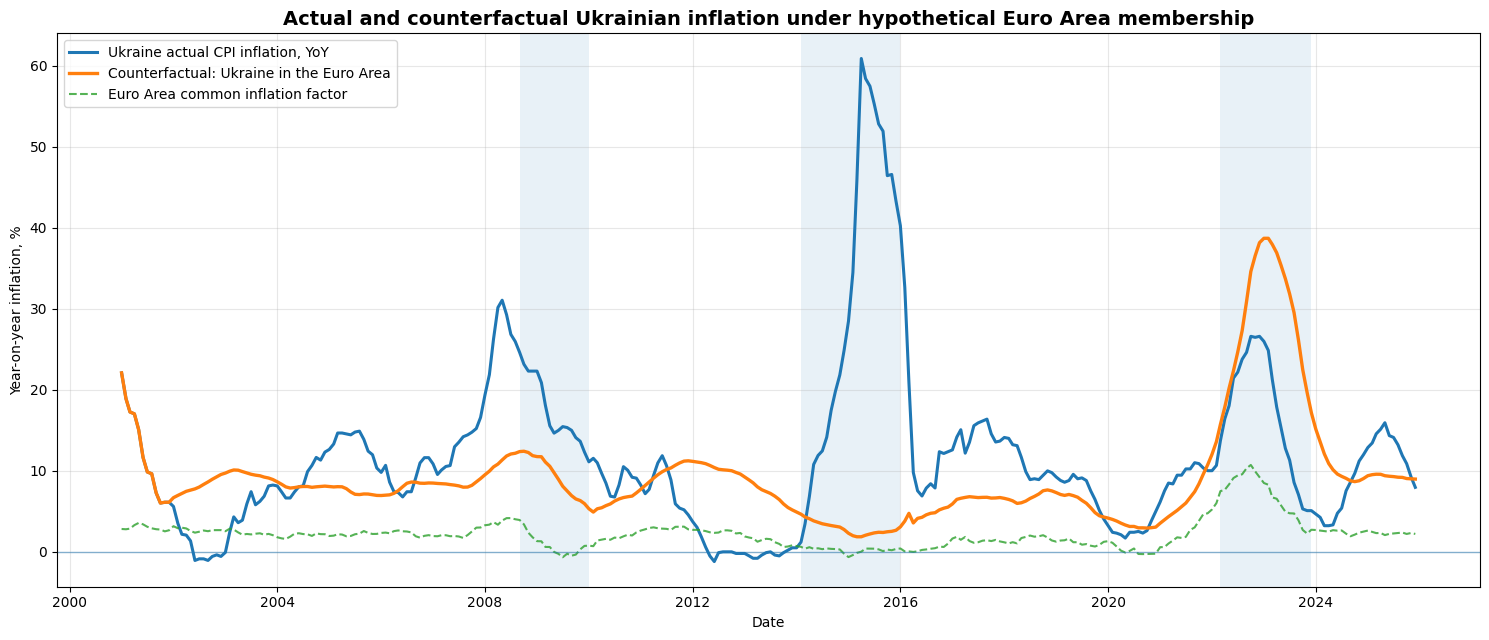

In [102]:

# ============================================================
# B.9.2 Main required figure: actual vs counterfactual inflation
# ============================================================

fig, ax = plt.subplots(figsize=(15, 6.5))

ax.plot(cf["date"], cf["pi_ukr_yoy"], linewidth=2.2, label="Ukraine actual CPI inflation, YoY")
ax.plot(cf["date"], cf["pi_cf"], linewidth=2.4, label="Counterfactual: Ukraine in the Euro Area")
ax.plot(cf["date"], cf["ea_factor"], linewidth=1.5, linestyle="--", alpha=0.8, label="Euro Area common inflation factor")

# Crisis windows
crisis_windows = [
    ("2008–09 GFC", "2008-09-01", "2010-01-01"),
    ("2014–15 Crimea/Donbas", "2014-02-01", "2016-01-01"),
    ("2022 full-scale invasion", "2022-02-24", "2023-12-01"),
]
for label, start, end in crisis_windows:
    ax.axvspan(pd.to_datetime(start), pd.to_datetime(end), alpha=0.10)

ax.axhline(0, linewidth=1, alpha=0.5)
ax.set_title("Actual and counterfactual Ukrainian inflation under hypothetical Euro Area membership", fontsize=14, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Year-on-year inflation, %")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figures/main_actual_vs_counterfactual_inflation.png", dpi=300)
plt.show()


In [103]:

# ============================================================
# B.9.3 Crisis-window summary table
# ============================================================

crisis_defs = [
    ("GFC and first peg break", "2008-09-01", "2010-01-01"),
    ("Crimea/Donbas and major devaluation", "2014-02-01", "2016-01-01"),
    ("Full-scale invasion and wartime regime", "2022-02-24", "2023-12-01"),
]

rows = []
for name, start, end in crisis_defs:
    sub = cf[(cf["date"] >= pd.to_datetime(start)) & (cf["date"] <= pd.to_datetime(end))].copy()
    rows.append({
        "episode": name,
        "start": start,
        "end": end,
        "actual_mean_inflation": sub["pi_ukr_yoy"].mean(),
        "counterfactual_mean_inflation": sub["pi_cf"].mean(),
        "mean_actual_minus_cf_gap": (sub["pi_ukr_yoy"] - sub["pi_cf"]).mean(),
        "max_actual_minus_cf_gap": (sub["pi_ukr_yoy"] - sub["pi_cf"]).max(),
        "mean_theta": sub["theta"].mean(),
    })

crisis_summary = pd.DataFrame(rows)
display(crisis_summary)
crisis_summary.to_csv("outputs/crisis_window_counterfactual_summary.csv", index=False)


,episode,start,end,actual_mean_inflation,counterfactual_mean_inflation,mean_actual_minus_cf_gap,max_actual_minus_cf_gap,mean_theta
0,GFC and first peg break,2008-09-01,2010-01-01,17.402176,9.378477,8.023699,12.233048,0.811765
1,Crimea/Donbas and major devaluation,2014-02-01,2016-01-01,31.957292,2.901170,29.056122,59.047621,0.989583
2,Full-scale invasion and wartime regime,2022-02-24,2023-12-01,17.290292,28.936138,-11.645846,-0.901749,0.422727



## B.9.4 Credibility sanity check: Giavazzi–Pagano mechanism

Giavazzi and Pagano's credibility-import argument implies a simple diagnostic for the counterfactual. If Euro Area membership works partly by importing the credibility of the ECB, the actual-minus-counterfactual inflation gap should be larger in the period in which the NBU had weaker monetary credibility, and smaller once Ukraine adopted an inflation-targeting framework.

This is not an additional identifying restriction. It is a **sanity check** on the economic interpretation of the baseline counterfactual. The check separates four periods:

1. **Pre-inflation-targeting period (2005–2015)**: weak credibility and repeated peg collapses.
2. **2014–2015 crisis window**: the most extreme credibility/exchange-rate shock.
3. **Inflation-targeting normal period (2016–2021)**: improved monetary framework before the full-scale invasion.
4. **Wartime period (2022–2025)**: treated separately because Euro Area inflation itself surged and Ukraine reintroduced wartime exchange-rate controls.


,period,start,end,n_months,actual_mean_inflation,counterfactual_mean_inflation,mean_actual_minus_cf_gap,median_actual_minus_cf_gap,max_actual_minus_cf_gap,mean_treatment_intensity
0,Pre-inflation-targeting / weak credibility,2005-01-01,2015-12-01,132,14.090511,7.584938,6.505573,4.025604,59.047621,0.418182
1,2014–2015 peg collapse and credibility shock,2014-02-01,2015-12-01,23,31.596527,2.893485,28.703041,26.193386,59.047621,1.000000
2,Inflation-targeting normal period,2016-01-01,2021-12-01,72,10.064140,5.606517,4.457623,3.175223,37.176981,0.750000
3,Wartime / exceptional regime,2022-02-01,2025-12-01,47,13.244659,18.867354,-5.622696,-3.527545,6.541543,0.545745


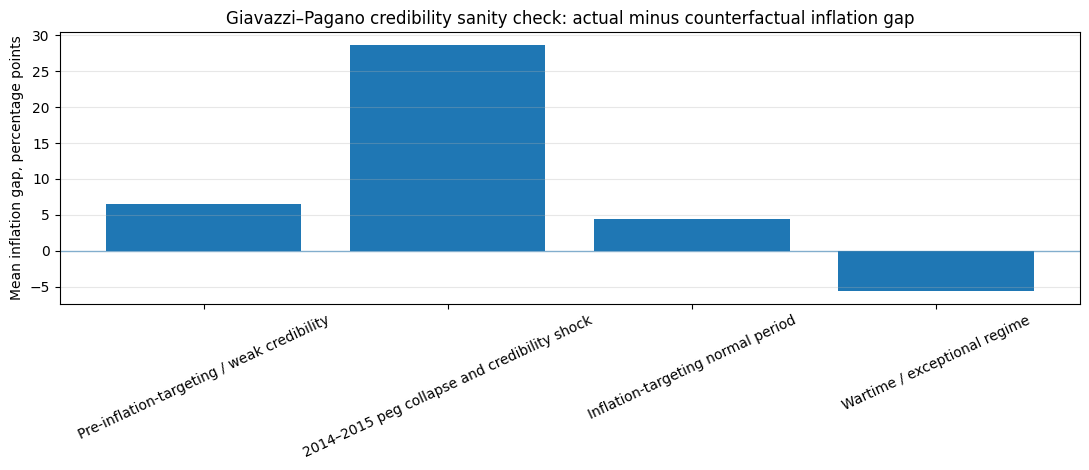

In [104]:

# ============================================================
# B.9.4 Giavazzi–Pagano credibility sanity check
# ============================================================

credibility_periods = [
    ("Pre-inflation-targeting / weak credibility", "2005-01-01", "2015-12-01"),
    ("2014–2015 peg collapse and credibility shock", "2014-02-01", "2015-12-01"),
    ("Inflation-targeting normal period", "2016-01-01", "2021-12-01"),
    ("Wartime / exceptional regime", "2022-02-01", "2025-12-01"),
]

cred_rows = []
for label, start, end in credibility_periods:
    sub = cf[(cf["date"] >= pd.to_datetime(start)) & (cf["date"] <= pd.to_datetime(end))].copy()
    sub = sub.dropna(subset=["pi_ukr_yoy", "pi_cf"])
    if len(sub) == 0:
        continue
    gap = sub["pi_ukr_yoy"] - sub["pi_cf"]
    cred_rows.append({
        "period": label,
        "start": start,
        "end": end,
        "n_months": int(len(sub)),
        "actual_mean_inflation": sub["pi_ukr_yoy"].mean(),
        "counterfactual_mean_inflation": sub["pi_cf"].mean(),
        "mean_actual_minus_cf_gap": gap.mean(),
        "median_actual_minus_cf_gap": gap.median(),
        "max_actual_minus_cf_gap": gap.max(),
        "mean_treatment_intensity": sub["theta"].mean(),
    })

credibility_check = pd.DataFrame(cred_rows)
display(credibility_check)
credibility_check.to_csv("outputs/giavazzi_pagano_credibility_sanity_check.csv", index=False)

# A compact visual diagnostic of the mean gap by regime.
fig, ax = plt.subplots(figsize=(11, 4.8))
ax.bar(credibility_check["period"], credibility_check["mean_actual_minus_cf_gap"])
ax.axhline(0, linewidth=1, alpha=0.5)
ax.set_title("Giavazzi–Pagano credibility sanity check: actual minus counterfactual inflation gap")
ax.set_ylabel("Mean inflation gap, percentage points")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=25)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("figures/giavazzi_pagano_sanity_check.png", dpi=300)
plt.show()



The credibility check should be read as a diagnostic rather than as a formal test. A larger positive gap before 2016 is consistent with the Giavazzi–Pagano mechanism: joining a credible monetary arrangement would have mattered most when domestic monetary credibility was weak and exchange-rate pegs repeatedly collapsed. A smaller gap in 2016–2021 is consistent with the NBU's move toward a more modern inflation-targeting regime. The wartime period is intentionally reported separately because it combines a war shock, administrative exchange-rate measures, capital restrictions and the Euro Area energy-inflation surge; it is therefore not a clean credibility experiment.



## B.10 Structural VAR benchmark: Blanchard–Quah shock replacement

The monthly baseline above is deliberately robust to the short and disrupted Ukrainian sample. However, the exam prompt also points toward the Bayoumi–Eichengreen / Blanchard–Quah tradition: identify **supply and demand disturbances** and ask what would have changed under monetary union.

This section therefore adds a structural benchmark. It is not used to discard the monthly baseline; it is used to show that the main counterfactual is consistent with a structural decomposition.

The SVAR is estimated at **annual frequency** because reliable real-activity data for both Ukraine and the Euro Area are more readily available annually. The model uses:

- real GDP growth, from the World Bank API;
- inflation, aggregated from the monthly inflation series already used in the notebook.

For each economy, a reduced-form VAR is estimated on:

`x_t = [real GDP growth_t, inflation_t]`

The Blanchard–Quah long-run restriction is imposed as follows:

- supply shocks may have a permanent effect on the level of output;
- demand shocks have no long-run effect on the level of output.

Since the first variable is output growth, the cumulative long-run effect on output is obtained from the long-run multiplier of the VAR in growth rates. The counterfactual keeps Ukraine-specific supply shocks, because Euro Area membership would not remove war, productivity, or sectoral supply disturbances. It replaces Ukraine-specific demand shocks with Euro Area demand shocks, because monetary-union membership would have subjected Ukraine to the ECB nominal-demand environment rather than a sovereign Ukrainian monetary policy reaction.

This is a **structural benchmark**, not a claim that annual SVAR estimates are more precise than the monthly baseline. Its role is to address the Blanchard–Quah identification logic explicitly and to test whether the main conclusion is qualitatively consistent with a supply/demand shock-replacement exercise.


In [105]:

# ============================================================
# B.10.1 Download World Bank real GDP growth for SVAR benchmark
# ============================================================

WORLD_BANK_BASE = "https://api.worldbank.org/v2/country/{country}/indicator/{indicator}?format=json&per_page=20000"
GDP_GROWTH_INDICATOR = "NY.GDP.MKTP.KD.ZG"  # GDP growth, annual %, constant local currency


def download_world_bank_indicator(country, indicator, local_path=None):
    """Download a World Bank indicator as a clean annual dataframe.

    Parameters
    ----------
    country : str
        World Bank country/area code. UKR = Ukraine; EMU = Euro area.
    indicator : str
        World Bank indicator code.
    local_path : str or None
        Optional local CSV cache.
    """
    local_path = Path(local_path) if local_path is not None else None

    if local_path is not None and local_path.exists():
        out = pd.read_csv(local_path)
        out["year"] = pd.to_numeric(out["year"], errors="coerce").astype("Int64")
        out["value"] = pd.to_numeric(out["value"], errors="coerce")
        return out.dropna(subset=["year", "value"]).assign(year=lambda x: x["year"].astype(int))

    url = WORLD_BANK_BASE.format(country=country, indicator=indicator)
    print(f"Downloading World Bank data: {country} / {indicator}")
    r = requests.get(url, timeout=90)
    r.raise_for_status()
    js = r.json()
    if not isinstance(js, list) or len(js) < 2 or js[1] is None:
        raise ValueError(f"Unexpected World Bank response for {country} {indicator}: {js[:1] if isinstance(js, list) else js}")

    rows = []
    for item in js[1]:
        rows.append({
            "year": int(item["date"]),
            "value": item["value"],
            "country": country,
            "indicator": indicator
        })
    out = pd.DataFrame(rows)
    out["value"] = pd.to_numeric(out["value"], errors="coerce")
    out = out.dropna(subset=["value"]).sort_values("year").reset_index(drop=True)

    if local_path is not None:
        local_path.parent.mkdir(parents=True, exist_ok=True)
        out.to_csv(local_path, index=False)

    return out

try:
    wb_ukr_gdp = download_world_bank_indicator("UKR", GDP_GROWTH_INDICATOR, "data/worldbank_ukr_gdp_growth.csv")
    wb_ea_gdp = download_world_bank_indicator("EMU", GDP_GROWTH_INDICATOR, "data/worldbank_emu_gdp_growth.csv")

    print("Ukraine GDP growth:")
    display(wb_ukr_gdp.tail())
    print("Euro Area GDP growth:")
    display(wb_ea_gdp.tail())
except Exception as e:
    raise RuntimeError(
        "World Bank GDP-growth download failed. The SVAR benchmark requires real-activity data. "
        "Check the internet connection and re-run this cell."
    ) from e


Ukraine GDP growth:


,year,value,country,indicator
32,2020,-3.752818,UKR,NY.GDP.MKTP.KD.ZG
33,2021,3.445621,UKR,NY.GDP.MKTP.KD.ZG
34,2022,-28.758584,UKR,NY.GDP.MKTP.KD.ZG
35,2023,5.534734,UKR,NY.GDP.MKTP.KD.ZG
36,2024,2.913822,UKR,NY.GDP.MKTP.KD.ZG


Euro Area GDP growth:


,year,value,country,indicator
59,2020,-6.056744,EMU,NY.GDP.MKTP.KD.ZG
60,2021,6.437138,EMU,NY.GDP.MKTP.KD.ZG
61,2022,3.659219,EMU,NY.GDP.MKTP.KD.ZG
62,2023,0.473406,EMU,NY.GDP.MKTP.KD.ZG
63,2024,0.911910,EMU,NY.GDP.MKTP.KD.ZG


In [106]:

# ============================================================
# B.10.2 Build annual SVAR dataset
# ============================================================

# Annual inflation series from the monthly data used in the main counterfactual.
annual_infl = (
    df.assign(year=df["date"].dt.year)
      .groupby("year", as_index=False)
      .agg(
          pi_ukr=("pi_ukr_yoy", "mean"),
          pi_ea=("ea_factor", "mean"),
          theta=("theta", "mean")
      )
)

ukr_gdp = wb_ukr_gdp.rename(columns={"value": "gdp_growth_ukr"})[["year", "gdp_growth_ukr"]]
ea_gdp = wb_ea_gdp.rename(columns={"value": "gdp_growth_ea"})[["year", "gdp_growth_ea"]]

svar_annual = (
    annual_infl
    .merge(ukr_gdp, on="year", how="inner")
    .merge(ea_gdp, on="year", how="inner")
    .sort_values("year")
    .reset_index(drop=True)
)

# Keep the sample used in the monthly project and drop crisis years only if the data are missing.
svar_annual = svar_annual[(svar_annual["year"] >= 2001) & (svar_annual["year"] <= 2025)].copy()

# If the most recent World Bank year is unavailable, the sample naturally stops earlier.
required_svar_cols = ["pi_ukr", "pi_ea", "gdp_growth_ukr", "gdp_growth_ea"]
svar_annual = svar_annual.dropna(subset=required_svar_cols).reset_index(drop=True)

if len(svar_annual) < 18:
    raise ValueError(
        f"The annual SVAR benchmark has only {len(svar_annual)} usable observations. "
        "This is too short even for a parsimonious BQ benchmark."
    )

print(f"Annual SVAR sample: {svar_annual['year'].min()}–{svar_annual['year'].max()} ({len(svar_annual)} observations)")
display(svar_annual.tail())

svar_annual.to_csv("outputs/svar_annual_dataset.csv", index=False)


Annual SVAR sample: 2001–2024 (24 observations)


,year,pi_ukr,pi_ea,theta,gdp_growth_ukr,gdp_growth_ea
19,2020,2.738285,0.197956,0.750000,-3.752818,-6.056744
20,2021,9.348689,2.321985,0.750000,3.445621,6.437138
21,2022,20.047764,8.583965,0.458333,-28.758584,3.659219
22,2023,13.374790,5.150343,0.441667,5.534734,0.473406
23,2024,6.487394,2.451609,0.650000,2.913822,0.911910


In [107]:

# ============================================================
# B.10.3 Blanchard–Quah decomposition utilities
# ============================================================

from statsmodels.tsa.api import VAR


def fit_bq_svar(data, output_col, infl_col, maxlags=2, name="economy"):
    """Estimate a bivariate Blanchard–Quah SVAR benchmark.

    Variables are ordered as [output growth, inflation]. The long-run restriction
    is that the second structural shock, interpreted as demand, has zero long-run
    effect on the level of output. With output growth in the VAR, this is imposed
    by triangularising the long-run multiplier.
    """
    y = data[[output_col, infl_col]].astype(float).dropna().copy()

    # Use a very parsimonious lag structure because the annual sample is short.
    # We let AIC choose between 1 and maxlags, but fallback to 1 if needed.
    model = VAR(y)
    selected_lag = 1
    try:
        order_res = model.select_order(maxlags=maxlags)
        aic_lag = order_res.selected_orders.get("aic", None)
        if aic_lag is not None and aic_lag >= 1:
            selected_lag = int(aic_lag)
    except Exception:
        selected_lag = 1

    selected_lag = max(1, min(selected_lag, maxlags))
    res = model.fit(selected_lag, trend="c")

    k = 2
    A_sum = np.zeros((k, k))
    for A in res.coefs:
        A_sum += A
    C1 = np.linalg.inv(np.eye(k) - A_sum)

    Sigma = np.asarray(res.sigma_u)
    long_run_cov = C1 @ Sigma @ C1.T

    # Numerical stabilisation in case the covariance matrix is near singular.
    long_run_cov = (long_run_cov + long_run_cov.T) / 2
    jitter = 1e-10 * np.eye(k)
    L = np.linalg.cholesky(long_run_cov + jitter)

    # L is lower triangular, so its (0,1) element is zero: demand has no long-run effect on output.
    B = np.linalg.inv(C1) @ L

    resid = np.asarray(res.resid)
    shocks = resid @ np.linalg.inv(B).T

    shock_df = data.iloc[selected_lag:].copy().reset_index(drop=True)
    shock_df[f"{name}_supply_shock"] = shocks[:, 0]
    shock_df[f"{name}_demand_shock"] = shocks[:, 1]

    out = {
        "name": name,
        "data": y,
        "res": res,
        "lag": selected_lag,
        "C1": C1,
        "B": B,
        "shocks": shock_df,
        "output_col": output_col,
        "infl_col": infl_col,
    }
    return out


ukr_bq = fit_bq_svar(svar_annual, "gdp_growth_ukr", "pi_ukr", maxlags=2, name="ukr")
ea_bq = fit_bq_svar(svar_annual, "gdp_growth_ea", "pi_ea", maxlags=2, name="ea")

print(f"Ukraine BQ-SVAR lag length: {ukr_bq['lag']}")
print(f"Euro Area BQ-SVAR lag length: {ea_bq['lag']}")
print("Ukraine impact matrix B:")
print(pd.DataFrame(ukr_bq["B"], index=["output_growth", "inflation"], columns=["supply_shock", "demand_shock"]))
print("Euro Area impact matrix B:")
print(pd.DataFrame(ea_bq["B"], index=["output_growth", "inflation"], columns=["supply_shock", "demand_shock"]))


Ukraine BQ-SVAR lag length: 1
Euro Area BQ-SVAR lag length: 2
Ukraine impact matrix B:
               supply_shock  demand_shock
output_growth      9.439502      0.173515
inflation         -4.279337      9.171549
Euro Area impact matrix B:
               supply_shock  demand_shock
output_growth      2.648769      0.420780
inflation          0.568866      1.250257


In [108]:

# ============================================================
# B.10.4 SVAR shock-replacement counterfactual
# ============================================================

# Align Ukraine and Euro Area structural shocks by year.
ukr_shocks = ukr_bq["shocks"][["year", "ukr_supply_shock", "ukr_demand_shock"]].copy()
ea_shocks = ea_bq["shocks"][["year", "ea_supply_shock", "ea_demand_shock"]].copy()
shock_panel = ukr_shocks.merge(ea_shocks, on="year", how="inner")

# Structural shocks from BQ are normalised. To avoid importing a different Euro Area volatility scale,
# we standardise the Euro Area demand shock and rescale it to the Ukraine demand-shock volatility.
pre_war = shock_panel["year"] <= 2021
ukr_demand_std = shock_panel.loc[pre_war, "ukr_demand_shock"].std()
ea_demand_std = shock_panel.loc[pre_war, "ea_demand_shock"].std()
if pd.isna(ukr_demand_std) or ukr_demand_std == 0 or pd.isna(ea_demand_std) or ea_demand_std == 0:
    shock_panel["ea_demand_scaled"] = shock_panel["ea_demand_shock"]
else:
    shock_panel["ea_demand_scaled"] = shock_panel["ea_demand_shock"] / ea_demand_std * ukr_demand_std

# The structural counterfactual keeps Ukraine supply shocks but replaces demand shocks.
shock_panel["cf_supply_shock"] = shock_panel["ukr_supply_shock"]
shock_panel["cf_demand_shock"] = shock_panel["ea_demand_scaled"]

# Recursive simulation of the Ukraine VAR with counterfactual structural shocks.
res = ukr_bq["res"]
B = ukr_bq["B"]
p = ukr_bq["lag"]
params = res.params
intercept = params.iloc[0].values
coefs = res.coefs

# Actual annual data in the Ukraine VAR order.
actual_y = svar_annual[["gdp_growth_ukr", "pi_ukr"]].astype(float).reset_index(drop=True)
years = svar_annual["year"].reset_index(drop=True)

# Initialise with actual pre-simulation lags.
y_cf = actual_y.copy().values
shock_lookup = shock_panel.set_index("year")

for t in range(p, len(actual_y)):
    year = int(years.iloc[t])

    # Start from VAR deterministic part plus lagged simulated values.
    pred = intercept.copy()
    for lag in range(1, p + 1):
        pred += coefs[lag - 1] @ y_cf[t - lag, :]

    if year in shock_lookup.index:
        eps_cf = shock_lookup.loc[year, ["cf_supply_shock", "cf_demand_shock"]].values.astype(float)
        u_cf = B @ eps_cf
        y_cf[t, :] = pred + u_cf
    else:
        # If no shock is available for a year, use actual values rather than inventing a shock.
        y_cf[t, :] = actual_y.iloc[t].values

svar_cf = svar_annual[["year", "pi_ukr", "pi_ea", "gdp_growth_ukr", "gdp_growth_ea"]].copy()
svar_cf["pi_bq_cf"] = y_cf[:, 1]
svar_cf["gdp_growth_bq_cf"] = y_cf[:, 0]
svar_cf = svar_cf.merge(shock_panel, on="year", how="left")

svar_cf.to_csv("outputs/bq_svar_counterfactual_annual.csv", index=False)
display(svar_cf.tail())


,year,pi_ukr,pi_ea,gdp_growth_ukr,gdp_growth_ea,pi_bq_cf,gdp_growth_bq_cf,ukr_supply_shock,ukr_demand_shock,ea_supply_shock,ea_demand_shock,ea_demand_scaled,cf_supply_shock,cf_demand_shock
19,2020,2.738285,0.197956,-3.752818,-6.056744,17.048865,-3.449385,-0.458004,-1.074898,-2.749808,0.425229,0.511315,-0.458004,0.511315
20,2021,9.348689,2.321985,3.445621,6.437138,24.072453,3.468793,0.311614,-0.088793,1.162286,1.084526,1.304084,0.311614,1.304084
21,2022,20.047764,8.583965,-28.758584,3.659219,47.831382,-28.510334,-3.117403,-0.444232,0.171361,1.962043,2.359251,-3.117403,2.359251
22,2023,13.374790,5.150343,5.534734,0.473406,19.964051,5.146323,0.690361,-0.363188,0.502922,-0.054725,-0.065804,0.690361,-0.065804
23,2024,6.487394,2.451609,2.913822,0.911910,11.071572,2.856233,0.233211,-0.369189,0.416635,0.016314,0.019616,0.233211,0.019616


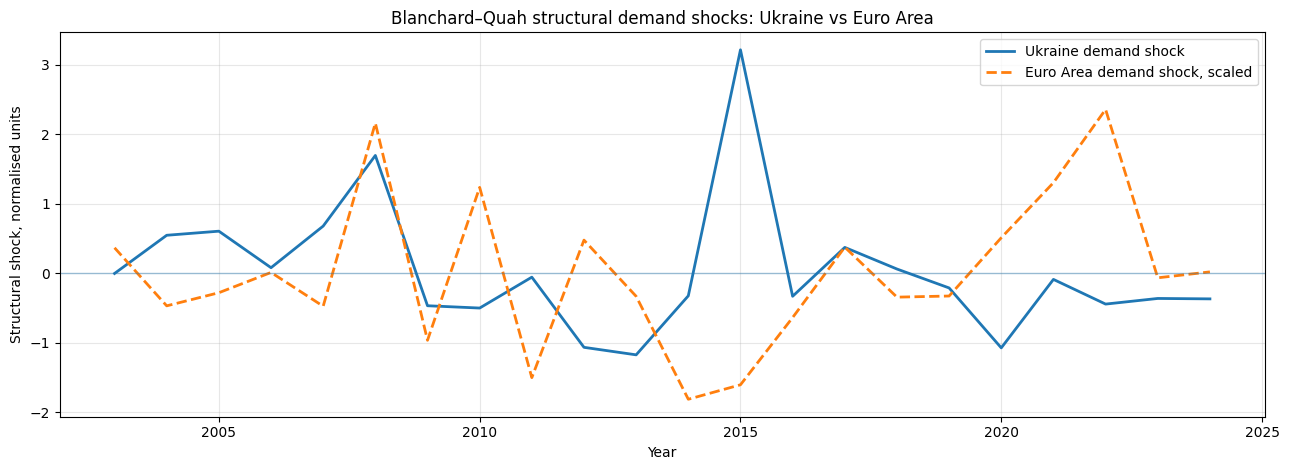

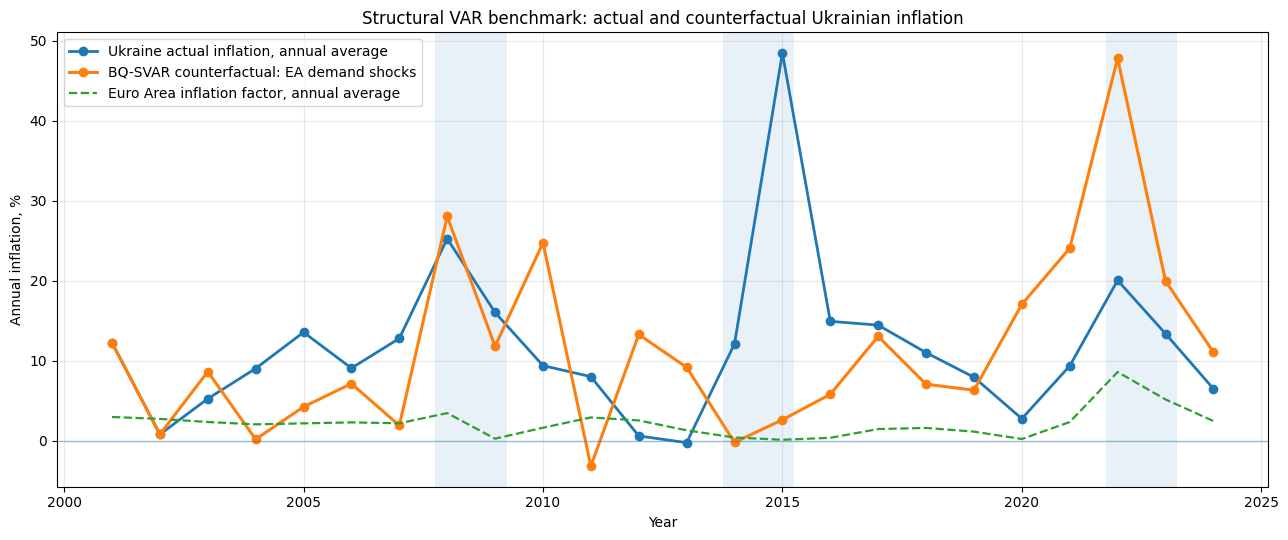

In [109]:

# ============================================================
# B.10.5 Plot BQ-SVAR structural shocks and annual counterfactual
# ============================================================

fig, ax = plt.subplots(figsize=(13, 4.8))
ax.plot(svar_cf["year"], svar_cf["ukr_demand_shock"], linewidth=2.0, label="Ukraine demand shock")
ax.plot(svar_cf["year"], svar_cf["ea_demand_scaled"], linewidth=2.0, linestyle="--", label="Euro Area demand shock, scaled")
ax.axhline(0, linewidth=1, alpha=0.4)
ax.set_title("Blanchard–Quah structural demand shocks: Ukraine vs Euro Area")
ax.set_xlabel("Year")
ax.set_ylabel("Structural shock, normalised units")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figures/bq_svar_demand_shocks.png", dpi=300)
plt.show()

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(svar_cf["year"], svar_cf["pi_ukr"], marker="o", linewidth=2.0, label="Ukraine actual inflation, annual average")
ax.plot(svar_cf["year"], svar_cf["pi_bq_cf"], marker="o", linewidth=2.2, label="BQ-SVAR counterfactual: EA demand shocks")
ax.plot(svar_cf["year"], svar_cf["pi_ea"], linewidth=1.6, linestyle="--", label="Euro Area inflation factor, annual average")

for start, end in [(2008, 2009), (2014, 2015), (2022, 2023)]:
    ax.axvspan(start - 0.25, end + 0.25, alpha=0.10)

ax.axhline(0, linewidth=1, alpha=0.4)
ax.set_title("Structural VAR benchmark: actual and counterfactual Ukrainian inflation")
ax.set_xlabel("Year")
ax.set_ylabel("Annual inflation, %")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figures/bq_svar_counterfactual_inflation.png", dpi=300)
plt.show()



## B.10.6 Blanchard–Quah forecast-error variance decomposition

A natural diagnostic for a Blanchard–Quah SVAR is a forecast-error variance decomposition (FEVD). The table below reports the share of the forecast-error variance of output growth and inflation explained by the identified **supply** and **demand** shocks at different horizons.

This output is useful for two reasons. First, it checks whether the structural decomposition behaves in a way that is economically interpretable. Second, it clarifies why the shock-replacement exercise is meaningful: if demand shocks explain a non-negligible share of inflation fluctuations, replacing Ukraine's demand shocks by Euro Area demand shocks is not merely cosmetic, but changes the inflation path through an identified structural channel.


,economy,variable,horizon_years,supply_shock_share_pct,demand_shock_share_pct
0,Ukraine,output_growth,1,99.97,0.03
1,Ukraine,inflation,1,17.88,82.12
2,Ukraine,output_growth,3,99.94,0.06
3,Ukraine,inflation,3,23.41,76.59
4,Ukraine,output_growth,5,99.94,0.06
5,Ukraine,inflation,5,23.42,76.58
6,Ukraine,output_growth,10,99.94,0.06
7,Ukraine,inflation,10,23.42,76.58
8,Euro Area,output_growth,1,97.54,2.46
9,Euro Area,inflation,1,17.15,82.85


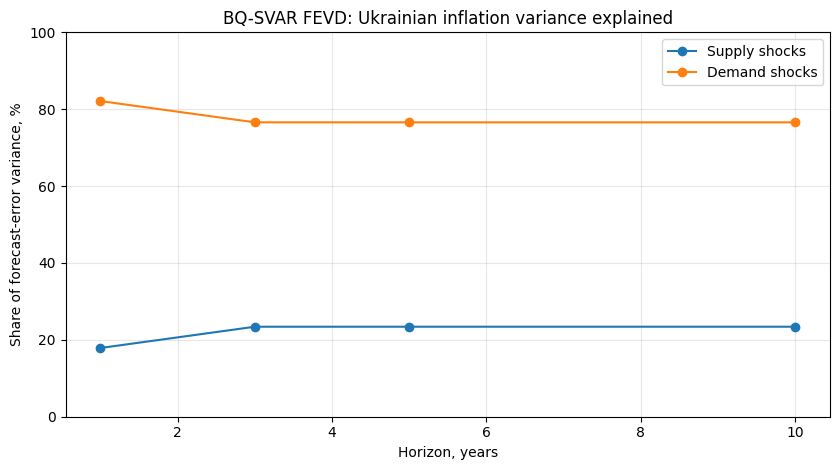

In [110]:

# ============================================================
# B.10.6 BQ-SVAR forecast-error variance decomposition (FEVD)
# ============================================================

def bq_fevd_table(bq_obj, horizons=(1, 3, 5, 10), economy_label="Ukraine"):
    """Compute a simple structural FEVD table for the BQ-SVAR.

    The VAR is y_t = ... + u_t, with u_t = B * eps_t.
    Structural shocks eps_t are orthogonal by construction.
    For each variable and horizon H, the FEVD share of shock j is:
        sum_{h=0}^{H-1} (Phi_h B)_{i,j}^2 / sum_j sum_{h=0}^{H-1} (Phi_h B)_{i,j}^2
    where Phi_h are the reduced-form moving-average coefficients.
    """
    res = bq_obj["res"]
    B = np.asarray(bq_obj["B"])
    max_h = max(horizons)
    ma = res.ma_rep(maxn=max_h)  # includes h=0

    rows = []
    var_names = ["output_growth", "inflation"]
    shock_names = ["supply", "demand"]

    for H in horizons:
        # Contributions from h=0,...,H-1
        structural_ma = np.array([ma[h] @ B for h in range(H)])
        contrib = (structural_ma ** 2).sum(axis=0)  # shape: variables x shocks
        total = contrib.sum(axis=1)

        for i, var in enumerate(var_names):
            if total[i] <= 0 or np.isnan(total[i]):
                supply_share = np.nan
                demand_share = np.nan
            else:
                supply_share = 100 * contrib[i, 0] / total[i]
                demand_share = 100 * contrib[i, 1] / total[i]
            rows.append({
                "economy": economy_label,
                "variable": var,
                "horizon_years": H,
                "supply_shock_share_pct": supply_share,
                "demand_shock_share_pct": demand_share,
            })

    return pd.DataFrame(rows)

ukr_fevd = bq_fevd_table(ukr_bq, horizons=(1, 3, 5, 10), economy_label="Ukraine")
ea_fevd = bq_fevd_table(ea_bq, horizons=(1, 3, 5, 10), economy_label="Euro Area")
bq_fevd = pd.concat([ukr_fevd, ea_fevd], ignore_index=True)

# Round only for display; save full precision.
display(bq_fevd.round(2))
bq_fevd.to_csv("outputs/bq_svar_fevd_supply_demand.csv", index=False)

# A compact display focused on Ukrainian inflation, the key object for the counterfactual.
ukr_infl_fevd = bq_fevd[(bq_fevd["economy"] == "Ukraine") & (bq_fevd["variable"] == "inflation")].copy()
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(ukr_infl_fevd["horizon_years"], ukr_infl_fevd["supply_shock_share_pct"], marker="o", label="Supply shocks")
ax.plot(ukr_infl_fevd["horizon_years"], ukr_infl_fevd["demand_shock_share_pct"], marker="o", label="Demand shocks")
ax.set_title("BQ-SVAR FEVD: Ukrainian inflation variance explained")
ax.set_xlabel("Horizon, years")
ax.set_ylabel("Share of forecast-error variance, %")
ax.set_ylim(0, 100)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figures/bq_svar_fevd_ukraine_inflation.png", dpi=300)
plt.show()



The FEVD table is reported as a diagnostic of the structural benchmark. The Blanchard–Quah restriction imposes that demand shocks have no long-run effect on the level of output, but it does not impose that demand shocks are irrelevant for inflation. If demand shocks explain a meaningful share of Ukrainian inflation variance at short or medium horizons, then the shock-replacement counterfactual has a clear economic interpretation: Euro Area membership is modelled as changing the demand-side nominal disturbance hitting Ukraine, while leaving country-specific supply disturbances in place. Because the sample is annual and short, the exact percentages should not be over-interpreted; the table is used to assess the plausibility and transparency of the structural decomposition.



 The structural benchmark should be interpreted at annual frequency and with caution, because the sample is short and Ukraine experiences very large regime breaks. Its value is identification-oriented: it explicitly implements the Bayoumi–Eichengreen idea that monetary union changes demand-side disturbances while country-specific supply disturbances remain domestic.

The key comparison is therefore not whether the annual SVAR exactly reproduces the smoother monthly counterfactual. The relevant question is whether the shock-replacement logic points in the same direction: when Ukraine experiences domestic demand and exchange-rate disturbances, replacing those disturbances with Euro Area demand shocks changes the inflation path materially. The 2014–2015 episode is especially informative because it combines a collapse of the hryvnia, a monetary-regime break, and a large inflation spike. The 2022 episode remains more ambiguous, because it combines a war-related supply shock, a wartime exchange-rate peg, and a historically large Euro Area energy-inflation shock.

This reinforces the main conclusion of the notebook: Euro Area membership would not simply have mechanically lowered inflation in all states of the world. It would have changed the adjustment mechanism by removing the exchange-rate/devaluation channel and importing Euro Area demand conditions, while leaving Ukraine-specific real shocks in place.


## B.11 Interpretation of the main result

The counterfactual should be read as a **monetary-regime counterfactual**, not as a claim that Euro Area membership would have eliminated Ukraine's real shocks.

The main result is regime-dependent.

- **2008–2009:** Euro Area membership would likely have reduced the inflationary consequences of the hryvnia depreciation, but it would also have removed an important external-adjustment mechanism. The counterfactual therefore captures lower exchange-rate pass-through, not the absence of the global financial crisis.

- **2014–2015:** this is the clearest episode in which monetary sovereignty was costly in inflation terms. Actual inflation rose sharply when the hryvnia peg collapsed, while the counterfactual removes most of this depreciation channel. The result should not be interpreted as implying that the Crimea/Donbas shock would have disappeared. Rather, monetary union would likely have changed the form of the crisis: less currency-inflation spiral, but potentially more internal devaluation, sovereign stress or real-side adjustment.

- **2022:** the interpretation is more nuanced. The model does **not** imply a mechanical inflation reduction from Euro Area membership. Euro Area inflation itself surged after the energy shock, while the NBU temporarily fixed the exchange rate and imposed wartime restrictions. As a result, the counterfactual may be close to (or even temporarily above) observed Ukrainian inflation. This is economically informative: the 2022 shock was not a standard exchange-rate crisis, but a war shock combining supply destruction, fiscal pressure, energy disruption and administrative controls.

Overall, monetary sovereignty gave Ukraine an exchange-rate buffer during crises, but that buffer came with high inflationary costs when devaluations occurred. Euro Area membership would have strengthened nominal anchoring and removed the hryvnia-depreciation channel, especially in 2014–2015. Its cost would have been the loss of a domestic adjustment instrument precisely when shocks were highly asymmetric.

The Giavazzi–Pagano credibility sanity check reinforces this interpretation by comparing the actual-minus-counterfactual inflation gap across monetary-regime periods. The expected pattern is not that the gap is constant, but that it is largest when domestic monetary credibility was weakest and devaluation pass-through was strongest, and more contained after the adoption of inflation targeting.


## B.12 Robustness: PDM-inspired Euro Area anchor

As a robustness exercise, the notebook constructs an alternative Euro Area inflation anchor using a simple Pioneer Detection Method-inspired weighting scheme.

The idea is not to assign equal weights to Euro Area countries. Instead, countries receive higher weight when their inflation movement appears to lead the cross-country panel in the direction in which the rest of the panel subsequently converges. This is consistent with the PDM logic in the course repository, where dynamic aggregation is used in environments with structural change and non-stationarity.

This robustness should be interpreted as a **stress test**, not as the preferred specification. The baseline counterfactual relies on the smoother PCA common factor. The PDM-inspired anchor is more reactive by construction, especially during abrupt inflation surges such as 2022. It is useful for assessing sensitivity to a more adaptive Euro Area anchor.

,date,pdm_anchor
0,2000-01-01,2.072727
1,2000-02-01,3.411111
2,2000-03-01,2.819444
3,2000-04-01,1.749006
4,2000-05-01,4.109524


,date,pdm_anchor
307,2025-08-01,2.600000
308,2025-09-01,2.409091
309,2025-10-01,2.000000
310,2025-11-01,3.374194
311,2025-12-01,0.958389


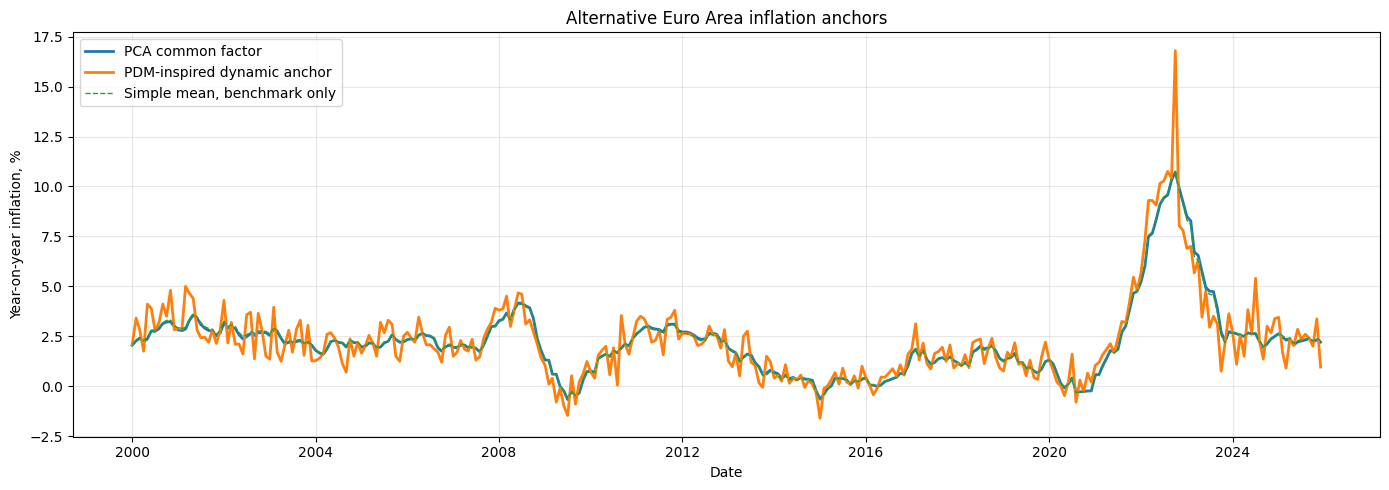

In [111]:

# ============================================================
# B.12 PDM-inspired Euro Area inflation anchor
# ============================================================

def compute_pdm_inspired_anchor(panel):
    """
    Simple PDM-inspired dynamic weighting for a country inflation panel.

    For each date t and country i:
    - compare distance of country i from the leave-one-out mean at t vs t-1;
    - check whether the leave-one-out mean moved more strongly than country i;
    - assign a directional-convergence weight;
    - normalize weights across countries;
    - if no pioneer is detected, fall back to equal weights.

    This is a transparent, self-contained robustness implementation inspired by the
    PDM logic in the repository. It is not used as the main identification strategy.
    """
    X = panel.copy().sort_index().interpolate(limit_direction="both")
    cols = list(X.columns)
    weights = pd.DataFrame(index=X.index, columns=cols, dtype=float)

    for t in range(len(X)):
        if t == 0:
            weights.iloc[t, :] = 1.0 / len(cols)
            continue
        x_t = X.iloc[t]
        x_tm1 = X.iloc[t - 1]
        raw_w = []
        for c in cols:
            others = [k for k in cols if k != c]
            m_t = x_t[others].mean()
            m_tm1 = x_tm1[others].mean()
            dist_t = abs(x_t[c] - m_t)
            dist_tm1 = abs(x_tm1[c] - m_tm1)
            distance_reduction = dist_t < dist_tm1
            move_i = abs(x_t[c] - x_tm1[c])
            move_others = abs(m_t - m_tm1)
            orientation = move_others > move_i
            if distance_reduction and orientation and (move_i + move_others) > 0:
                raw_w.append(move_others / (move_i + move_others))
            else:
                raw_w.append(0.0)
        raw_w = np.array(raw_w, dtype=float)
        if raw_w.sum() <= 0 or np.isnan(raw_w).all():
            raw_w = np.ones(len(cols)) / len(cols)
        else:
            raw_w = raw_w / raw_w.sum()
        weights.iloc[t, :] = raw_w

    anchor = (X * weights).sum(axis=1)
    return pd.DataFrame({"date": X.index, "pdm_anchor": anchor.values}), weights

pdm_anchor, pdm_weights = compute_pdm_inspired_anchor(ea_for_pca)
display(pdm_anchor.head())
display(pdm_anchor.tail())

# Plot comparison of anchors
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ea_factor["date"], ea_factor["ea_factor"], linewidth=2.0, label="PCA common factor")
ax.plot(pdm_anchor["date"], pdm_anchor["pdm_anchor"], linewidth=2.0, label="PDM-inspired dynamic anchor")
ax.plot(ea_factor["date"], ea_factor["ea_mean"], linewidth=1.0, linestyle="--", label="Simple mean, benchmark only")
ax.set_title("Alternative Euro Area inflation anchors")
ax.set_xlabel("Date")
ax.set_ylabel("Year-on-year inflation, %")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figures/alternative_ea_anchors_pdm.png", dpi=300)
plt.show()


,p,usable_rows,prewar_rows,n_parameters,min_required
0,1,299,251,7,24
1,2,298,250,9,24
2,3,297,249,11,24
3,4,296,248,13,24
4,5,295,247,15,24
5,6,294,246,17,25


Selected lag length for PDM-anchor robustness: p = 6


,p,AIC,BIC,nobs,n_params
0,6,801.929101,858.014406,246,17
1,5,809.502589,858.634025,247,15
2,4,814.717892,856.879037,248,13
3,3,856.863567,892.038096,249,11
4,2,913.917128,942.088816,250,9
5,1,1017.315215,1038.467932,251,7


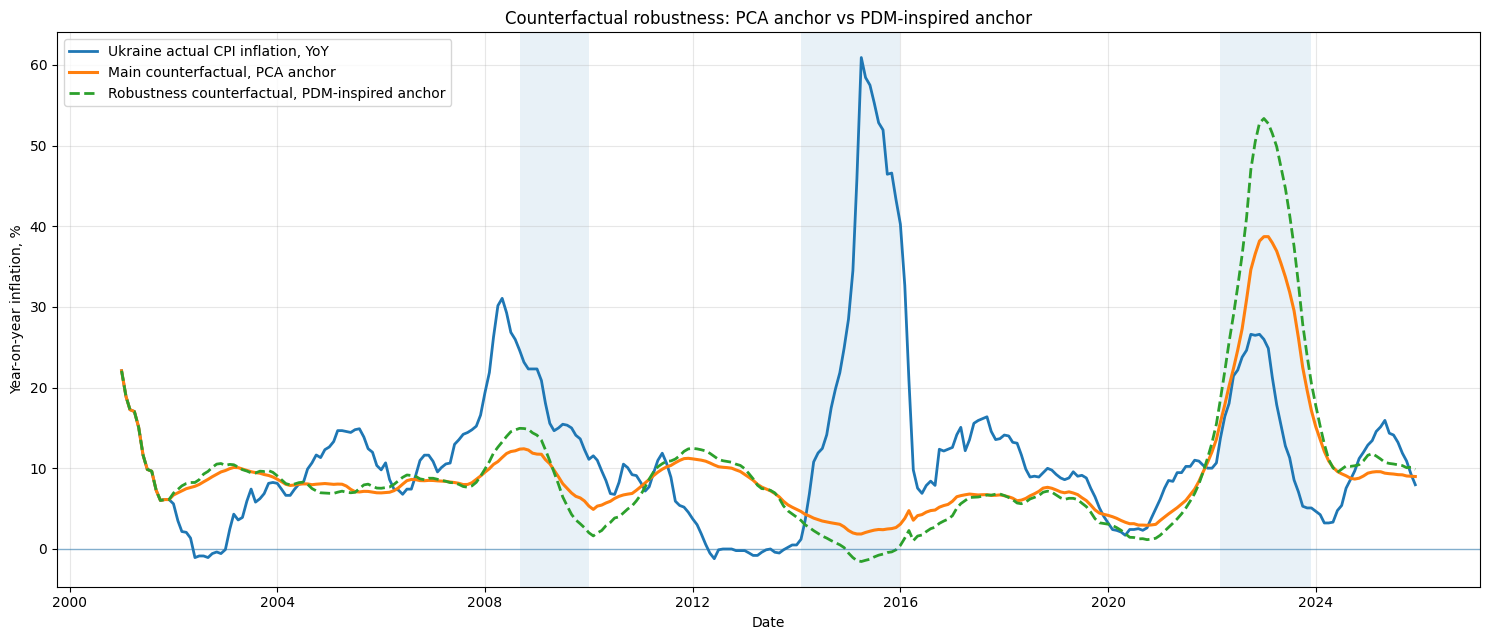

In [112]:
# ============================================================
# B.12.1 Robustness counterfactual using PDM-inspired anchor
# ============================================================

# Merge PDM anchor into modelling data.
df_pdm = df.merge(pdm_anchor, on="date", how="left")
df_pdm["pdm_anchor"] = df_pdm["pdm_anchor"].interpolate(limit_direction="both")
df_pdm["ea_factor_pdm"] = df_pdm["pdm_anchor"]

try:
    best_p_pdm, lag_table_pdm = select_lag_aic(df_pdm, max_p=6, train_end="2021-12-01", anchor_col="ea_factor_pdm")
    print(f"Selected lag length for PDM-anchor robustness: p = {best_p_pdm}")
    display(lag_table_pdm)

    pdm_model, pdm_model_df, pdm_xcols = fit_main_model(df_pdm, best_p_pdm, train_end="2021-12-01", anchor_col="ea_factor_pdm")
    cf_pdm = recursive_counterfactual(df_pdm, pdm_model, best_p_pdm, anchor_col="ea_factor_pdm")
    cf_pdm = cf_pdm.rename(columns={"pi_cf": "pi_cf_pdm_anchor"})

    # Merge robustness series into main counterfactual dataframe.
    cf_robust = cf.merge(cf_pdm[["date", "pi_cf_pdm_anchor"]], on="date", how="left")
    cf_robust.to_csv("outputs/counterfactual_with_pdm_robustness.csv", index=False)

    fig, ax = plt.subplots(figsize=(15, 6.5))
    ax.plot(cf_robust["date"], cf_robust["pi_ukr_yoy"], linewidth=2.0, label="Ukraine actual CPI inflation, YoY")
    ax.plot(cf_robust["date"], cf_robust["pi_cf"], linewidth=2.2, label="Main counterfactual, PCA anchor")
    ax.plot(cf_robust["date"], cf_robust["pi_cf_pdm_anchor"], linewidth=2.0, linestyle="--", label="Robustness counterfactual, PDM-inspired anchor")

    for label, start, end in crisis_windows:
        ax.axvspan(pd.to_datetime(start), pd.to_datetime(end), alpha=0.10)

    ax.axhline(0, linewidth=1, alpha=0.5)
    ax.set_title("Counterfactual robustness: PCA anchor vs PDM-inspired anchor")
    ax.set_xlabel("Date")
    ax.set_ylabel("Year-on-year inflation, %")
    ax.legend(loc="upper left")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("figures/counterfactual_robustness_pdm_anchor.png", dpi=300)
    plt.show()

except Exception as e:
    print("PDM-anchor robustness could not be completed. The main counterfactual remains valid.")
    print("Reason:", repr(e))
    cf_robust = cf.copy()
    cf_robust["pi_cf_pdm_anchor"] = np.nan
    cf_robust.to_csv("outputs/counterfactual_with_pdm_robustness.csv", index=False)


## B.13 Robustness and limitations

The PDM-inspired robustness does not mechanically “confirm” the baseline result. Rather, it checks how sensitive the counterfactual is to a more reactive Euro Area inflation anchor.

The main qualitative conclusion for **2014–2015** is robust: attenuating the hryvnia-depreciation channel substantially lowers counterfactual inflation relative to actual Ukrainian inflation. This is the episode where the monetary-regime mechanism is most clearly identified.

The **2022** episode is more sensitive. A more reactive PDM-inspired anchor can amplify the common European energy-inflation shock and generate a higher counterfactual inflation path than the baseline. This does not invalidate the exercise; it reinforces the interpretation that the 2022 crisis cannot be reduced to a standard exchange-rate pass-through episode. It was a war shock with supply, fiscal, energy and institutional dimensions.

Several limitations remain and should be acknowledged:

1. **No counterfactual can observe the true Ukraine-in-the-Euro-Area path.** The exercise is structural and model-based.
2. **Euro Area membership would not remove real shocks.** In 2014 and 2022, geopolitical shocks would remain highly asymmetric.
3. **The model focuses on the inflation channel.** It does not fully model sovereign-risk, fiscal-discipline, lender-of-last-resort mechanisms or fiscal transfers.
4. **Treatment intensity is theoretically disciplined but still calibrated.** It is anchored in Part A, yet alternative calibrations should be considered in extensions.
5. **The PDM-inspired anchor is deliberately adaptive.** It is therefore best viewed as a stress test rather than as the baseline nominal anchor.

These limitations do not invalidate the exercise; they clarify what the counterfactual is and is not measuring.

In [113]:

# ============================================================
# B.14 Export summary outputs
# ============================================================

summary = {
    "sample_start": str(df["date"].min().date()),
    "sample_end": str(df["date"].max().date()),
    "n_months": int(len(df)),
    "selected_lag_main": int(best_p),
    "first_pc_variance_explained": float(var_explained_1),
    "main_model_train_end": "2021-12-01",
    "external_data_used": "NBU UAH/USD official exchange rate; Brent oil price from FRED when available; World Bank real GDP growth for Ukraine and Euro Area used in BQ-SVAR benchmark",
    "bq_svar_lag_ukraine": int(ukr_bq["lag"]) if "ukr_bq" in globals() else None,
    "bq_svar_lag_euro_area": int(ea_bq["lag"]) if "ea_bq" in globals() else None,
    "giavazzi_pagano_check_included": "credibility_check" in globals(),
    "bq_svar_fevd_included": "bq_fevd" in globals(),
}

summary_df = pd.DataFrame([summary])
display(summary_df)
summary_df.to_csv("outputs/project_summary_partB.csv", index=False)

print("Main files created:")
for f in [
    "outputs/modelling_dataset_partB.csv",
    "outputs/main_counterfactual_series.csv",
    "outputs/counterfactual_with_pdm_robustness.csv",
    "figures/main_actual_vs_counterfactual_inflation.png",
    "figures/lp_exchange_rate_passthrough.png",
    "figures/counterfactual_robustness_pdm_anchor.png",
    "figures/giavazzi_pagano_sanity_check.png",
    "figures/bq_svar_fevd_ukraine_inflation.png",
    "outputs/giavazzi_pagano_credibility_sanity_check.csv",
    "outputs/bq_svar_fevd_supply_demand.csv",
]:
    print(" -", f)


,sample_start,sample_end,n_months,selected_lag_main,first_pc_variance_explained,main_model_train_end,external_data_used,bq_svar_lag_ukraine,bq_svar_lag_euro_area,giavazzi_pagano_check_included,bq_svar_fevd_included
0,2001-01-01,2025-12-01,300,6,0.801577,2021-12-01,NBU UAH/USD official exchange rate; Brent oil price from FRED when available; World Bank real GDP growth for Ukraine...,1,2,True,True


Main files created:
 - outputs/modelling_dataset_partB.csv
 - outputs/main_counterfactual_series.csv
 - outputs/counterfactual_with_pdm_robustness.csv
 - figures/main_actual_vs_counterfactual_inflation.png
 - figures/lp_exchange_rate_passthrough.png
 - figures/counterfactual_robustness_pdm_anchor.png
 - figures/giavazzi_pagano_sanity_check.png
 - figures/bq_svar_fevd_ukraine_inflation.png
 - outputs/giavazzi_pagano_credibility_sanity_check.csv
 - outputs/bq_svar_fevd_supply_demand.csv


# Final conclusion

This project constructs a counterfactual inflation path for Ukraine under hypothetical Euro Area membership by combining monetary-regime evidence with an explicit econometric identification strategy and a structural Blanchard–Quah SVAR benchmark, a FEVD diagnostic of supply versus demand shocks, and a Giavazzi–Pagano credibility sanity check.

The main conclusion is not simply that Euro Area membership would have produced “lower inflation.” Rather, the exercise shows that the **value and cost of monetary sovereignty are regime-dependent**. When Ukraine was already constrained by a peg, the additional monetary-regime treatment would have been limited. During periods of large devaluation and genuine monetary autonomy, however, Euro Area membership would have significantly altered the inflation process by removing the hryvnia-depreciation channel and strengthening the nominal anchor.

The strongest result concerns **2014–2015**: the collapse of the hryvnia generated an inflationary spiral that a monetary-union regime would likely have dampened. The result for **2022** is more ambiguous and should be interpreted carefully. Because Euro Area inflation itself surged after the energy shock and because Ukraine temporarily fixed the exchange rate under wartime conditions, the counterfactual does not mechanically imply lower inflation during the full-scale invasion.

The broader OCA interpretation is therefore nuanced. The euro could have reduced inflationary exchange-rate pass-through and imported credibility, but it would also have removed a key adjustment instrument in the face of asymmetric geopolitical shocks. In other words, monetary union would not eliminate crises; it would change their transmission mechanism — from currency and inflation crises toward internal devaluation, fiscal pressure and real-side adjustment.

Two additional diagnostics strengthen the final interpretation. First, the Giavazzi–Pagano sanity check verifies whether the counterfactual gap is larger in the low-credibility pre-inflation-targeting period and more contained after 2016. Second, the BQ-SVAR variance decomposition reports how much of inflation and output-growth uncertainty is accounted for by supply and demand shocks, making the structural shock-replacement exercise more transparent.



# References for Part B

- Abadie, A., Diamond, A., and Hainmueller, J. (2010). Synthetic control methods for comparative case studies. *Journal of the American Statistical Association*.
- Bayoumi, T., and Eichengreen, B. (1993). Shocking aspects of European monetary integration.
- Blanchard, O. J., and Quah, D. (1989). The dynamic effects of aggregate demand and supply disturbances.
- Ciccarelli, M., and Mojon, B. (2010). Global inflation. *Review of Economics and Statistics*.
- Jordà, Ò. (2005). Estimation and inference of impulse responses by local projections. *American Economic Review*.
- Kilian, L., and Lütkepohl, H. (2017). *Structural Vector Autoregressive Analysis*.
- National Bank of Ukraine. Official exchange-rate API and monetary-policy documentation.
- Federal Reserve Bank of St. Louis (FRED). Brent crude oil price series DCOILBRENTEU.
- Vansteenberghe, E. (2025). Pioneer Detection Method, course repository and associated implementation.

- World Bank, World Development Indicators: GDP growth (annual %) for Ukraine and Euro Area, downloaded through the World Bank API.
